In [1]:
from OpenGL.GL import *
from OpenGL.GLU import *
from OpenGL.GLUT import *
import sys
import numpy as np


In [2]:

# --- load data ---
vertices, normals_flat, normals_smooth, colors, uvs = (lambda d: (d["vertices"], d["normals_flat"], d["normals_smooth"], d["colors"], d["uvs"])) (np.load("object_vbo.npz"))



In [3]:
# Global interaction parameters
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800



In [4]:
def init_gl():
    """Initialize OpenGL settings."""
    glClearColor(0.1, 0.12, 0.15, 1.0)
    glEnable(GL_DEPTH_TEST)

    # lighting
    glEnable(GL_LIGHTING)
    glEnable(GL_LIGHT0)
    glLightfv(GL_LIGHT0, GL_POSITION, (5.0, 5.0, 5.0, 1.0))
    glLightfv(GL_LIGHT0, GL_DIFFUSE, (1.0, 1.0, 1.0, 1.0))
    glLightfv(GL_LIGHT0, GL_AMBIENT, (0.2, 0.2, 0.2, 1.0))

    # material
    glColorMaterial(GL_FRONT_AND_BACK, GL_AMBIENT_AND_DIFFUSE)
    glEnable(GL_COLOR_MATERIAL)
    glColor3f(0.8, 0.65, 0.25)



In [5]:
def display():
    """Render the mesh."""
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)
    glLoadIdentity()

    gluLookAt(0, 0, distance, 0, 0, 0, 0, 1, 0)
    glRotatef(angle_x, 1, 0, 0)
    glRotatef(angle_y, 0, 1, 0)

    # draw mesh
    glEnableClientState(GL_VERTEX_ARRAY)
    glEnableClientState(GL_NORMAL_ARRAY)

    glVertexPointerf(vertices)
    glNormalPointerf(normals_flat)

    glDrawArrays(GL_TRIANGLES, 0, len(vertices))

    glDisableClientState(GL_NORMAL_ARRAY)
    glDisableClientState(GL_VERTEX_ARRAY)

    glutSwapBuffers()




In [6]:
def reshape(width, height):
    """Handle window resize."""
    global window_width, window_height
    window_width, window_height = width, height
    glViewport(0, 0, width, height)
    glMatrixMode(GL_PROJECTION)
    glLoadIdentity()
    aspect = width / max(1, height)
    gluPerspective(45.0, aspect, 0.1, 100.0)
    glMatrixMode(GL_MODELVIEW)



In [7]:
def idle():
    glutPostRedisplay()



In [8]:
# =============================================================
#  INTERACTION HANDLERS
# =============================================================

def mouse(button, state, x, y):
    """Mouse button handler."""
    global mouse_button, distance

    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    # scroll zoom
    if button == 3:  # scroll up
        distance = max(1.0, distance - 0.3)
    elif button == 4:  # scroll down
        distance = min(50.0, distance + 0.3)


def motion(x, y):
    """Mouse drag handler."""
    global last_x, last_y, angle_x, angle_y, distance

    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))



def passive_motion(x, y):
    """Track last position without pressing a button."""
    global last_x, last_y
    last_x, last_y = x, y


def keyboard(key, x, y):
    """Keyboard shortcuts."""
    if key == b'q' or key == b'\x1b':  # ESC
        print("[INFO] Exiting viewer.")
        glutLeaveMainLoop()
        sys.exit(0)


def close():
    print("[INFO] Window closed.")
    sys.exit(0)


In [9]:
# =============================================================
#  MAIN
# =============================================================

def main():
    """Run the OpenGL viewer."""
    global vertices, normals_flat

    if vertices is None or len(vertices) == 0:
        print("[ERROR] vertices array is empty.")
        return

    print(f"[INFO] Loaded {len(vertices)} vertices.")

    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"3D Mesh Viewer")

    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutWMCloseFunc(close)

    glutMainLoop()
    

In [ ]:
# =============================================================
#  RUN VIEWER
# =============================================================

if __name__ == "__main__":
    main()

[INFO] Loaded 4680 vertices.


Exception ignored on calling ctypes callback function: <function GLUTCallback.__call__.<locals>.safeCall at 0x000001E8CCA9CFE0>
Traceback (most recent call last):
  File "C:\Users\Arafat\AppData\Local\Programs\Python\Python312\Lib\site-packages\OpenGL\GLUT\special.py", line 130, in safeCall
    return function( *args, **named )
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Arafat\AppData\Local\Temp\ipykernel_3076\590207187.py", line 55, in close
SystemExit: 0


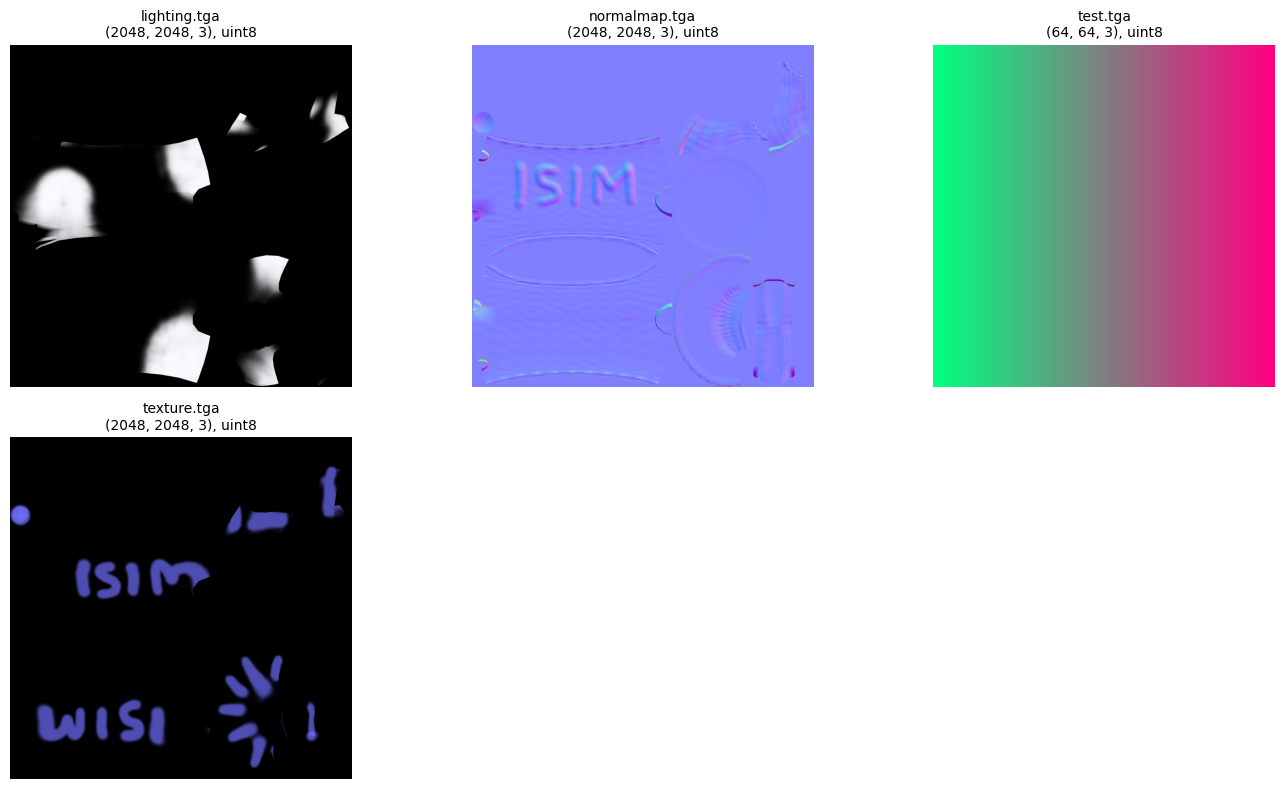


=== object_vbo.npz ===
Keys: ['vertices', 'normals_flat', 'normals_smooth', 'colors', 'uvs']
  vertices: shape=(4680, 3), dtype=float32
  normals_flat: shape=(4680, 3), dtype=float32
  normals_smooth: shape=(4680, 3), dtype=float32
  colors: shape=(4680, 3), dtype=float32
  uvs: shape=(4680, 2), dtype=float32


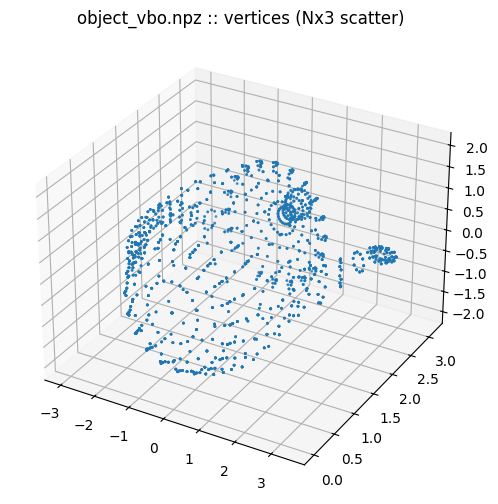

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --- TGA loading (use PIL if available, else imageio) ---
def load_tga(path):
    try:
        from PIL import Image
        img = Image.open(path)
        return np.array(img)
    except Exception:
        import imageio.v2 as imageio
        return imageio.imread(path)

def show_image_grid(images, titles, cols=3, figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), 1):
        ax = plt.subplot(rows, cols, i)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
    plt.tight_layout()
    plt.show()

# --- NPZ "best effort" visualizer (prints keys + tries simple plots) ---
def visualize_npz(path):
    data = np.load(path, allow_pickle=True)
    keys = list(data.keys())
    print(f"\n=== {os.path.basename(path)} ===")
    print("Keys:", keys)

    # Print shapes/dtypes
    for k in keys:
        arr = data[k]
        if isinstance(arr, np.ndarray):
            print(f"  {k}: shape={arr.shape}, dtype={arr.dtype}")
        else:
            print(f"  {k}: type={type(arr)}")

    # Try to find something plottable:
    # 1) If any array looks like Nx3 or Nx2, scatter it
    for k in keys:
        arr = data[k]
        if isinstance(arr, np.ndarray) and arr.ndim == 2 and arr.shape[1] in (2, 3) and arr.shape[0] >= 3:
            pts = arr.astype(float)
            if pts.shape[1] == 2:
                plt.figure(figsize=(6, 6))
                plt.scatter(pts[:, 0], pts[:, 1], s=1)
                plt.title(f"{os.path.basename(path)} :: {k} (Nx2 scatter)")
                plt.gca().set_aspect("equal", adjustable="box")
                plt.show()
            else:
                fig = plt.figure(figsize=(7, 6))
                ax = fig.add_subplot(111, projection="3d")
                ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=1)
                ax.set_title(f"{os.path.basename(path)} :: {k} (Nx3 scatter)")
                plt.show()
            break

    # 2) If any array looks like an image (HxW) or (HxWxC), show the first one
    for k in keys:
        arr = data[k]
        if isinstance(arr, np.ndarray) and arr.ndim in (2, 3):
            # Heuristic: big 2D/3D arrays might be image-like
            if arr.ndim == 2 and arr.shape[0] >= 16 and arr.shape[1] >= 16:
                plt.figure(figsize=(6, 6))
                plt.imshow(arr, cmap="gray")
                plt.title(f"{os.path.basename(path)} :: {k} (2D array)")
                plt.axis("off")
                plt.show()
                break
            if arr.ndim == 3 and arr.shape[0] >= 16 and arr.shape[1] >= 16 and arr.shape[2] in (1, 3, 4):
                plt.figure(figsize=(6, 6))
                plt.imshow(arr)
                plt.title(f"{os.path.basename(path)} :: {k} (3D array)")
                plt.axis("off")
                plt.show()
                break

# --------- Run on all files in a folder (excluding .ipynb) ---------
folder = "."  # change if needed
files = sorted([f for f in os.listdir(folder) if not f.lower().endswith(".ipynb")])

tga_files = [f for f in files if f.lower().endswith(".tga")]
npz_files = [f for f in files if f.lower().endswith(".npz")]

# Visualize all .tga in a grid
if tga_files:
    imgs, titles = [], []
    for f in tga_files:
        p = os.path.join(folder, f)
        img = load_tga(p)
        imgs.append(img)
        titles.append(f"{f}\n{img.shape}, {img.dtype}")
    show_image_grid(imgs, titles, cols=3)

# Visualize all .npz (prints keys + best-effort plots)
for f in npz_files:
    visualize_npz(os.path.join(folder, f))


### 2. The color 2.2 and 2.3

In [ ]:
from OpenGL.GL import *
from OpenGL.GLU import *
from OpenGL.GLUT import *
import sys
import numpy as np
import math

# --- load data ---
d = np.load("object_vbo.npz")
vertices = d["vertices"].astype(np.float32)   # (N,3)
colors   = d["colors"].astype(np.float32)     # (N,3)

# Global interaction parameters
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# GL objects
vao = None
vbo_pos = None
vbo_col = None

prog_smooth = None   # Q2.1 / Q2.2 (interpolated color)
prog_flat   = None   # Q2.3 (no interpolation)
current_prog = None

# ------------------------------------------------------------
# Minimal matrix helpers (so we don't rely on fixed pipeline)
# ------------------------------------------------------------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)

    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)

    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    # OpenGL expects column-major; numpy uses row-major.
    return M.T

# ------------------------------------------------------------
# Shader compile/link helpers
# ------------------------------------------------------------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ------------------------------------------------------------
# Q2 shaders
# ------------------------------------------------------------
VS_SMOOTH = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_col;

uniform mat4 uMVP;

out vec3 vCol;

void main() {
    vCol = in_col;                 // interpolated by default
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_SMOOTH = """
#version 330 core
in vec3 vCol;
out vec4 outColor;
void main() {
    outColor = vec4(vCol, 1.0);
}
"""

VS_FLAT = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_col;

uniform mat4 uMVP;

flat out vec3 vCol;                // NO interpolation
void main() {
    vCol = in_col;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_FLAT = """
#version 330 core
flat in vec3 vCol;
out vec4 outColor;
void main() {
    outColor = vec4(vCol, 1.0);
}
"""

# =============================================================
#  THREE REQUIRED FUNCTIONS (your Q2.1 / Q2.2 / Q2.3)
# =============================================================

def mode_smooth():
    """Q2.1 -> Smooth (default interpolation)."""
    global current_prog
    current_prog = prog_smooth
    print("[MODE] Smooth (interpolated VBO color)")

def mode_colored_pot():
    """Q2.2 -> Colored the pot using VBO color."""
    global current_prog
    current_prog = prog_smooth
    print("[MODE] Colored pot (VBO color)")

def mode_triangle_colors():
    """Q2.3 -> Triangle shape color (disable interpolation)."""
    global current_prog
    current_prog = prog_flat
    print("[MODE] Triangle colors (flat / no interpolation)")

# =============================================================
#  OpenGL init
# =============================================================
def init_gl():
    global vao, vbo_pos, vbo_col, prog_smooth, prog_flat, current_prog

    glClearColor(0.1, 0.12, 0.15, 1.0)
    glEnable(GL_DEPTH_TEST)

    # compile programs
    prog_smooth = link_program(VS_SMOOTH, FS_SMOOTH)
    prog_flat   = link_program(VS_FLAT,   FS_FLAT)
    current_prog = prog_smooth

    # Create VAO/VBOs
    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # positions -> location 0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # colors -> location 1
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

# =============================================================
#  Render
# =============================================================
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    # Build MVP from your interaction variables
    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)
    loc = glGetUniformLocation(current_prog, "uMVP")
    glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glUseProgram(0)
    glutSwapBuffers()

def reshape(width, height):
    global window_width, window_height
    window_width, window_height = width, height
    glViewport(0, 0, width, height)

def idle():
    glutPostRedisplay()

# =============================================================
#  Interaction handlers (mostly your original)
# =============================================================
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    if button == 3:  # scroll up
        distance = max(1.0, distance - 0.3)
    elif button == 4:  # scroll down
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    if key in (b'q', b'\x1b'):
        print("[INFO] Exiting viewer.")
        glutLeaveMainLoop()
        sys.exit(0)

    # Mode switching
    if key == b'1':
        mode_smooth()
    elif key == b'2':
        mode_colored_pot()
    elif key == b'3':
        mode_triangle_colors()

def close():
    print("[INFO] Window closed.")
    sys.exit(0)

# =============================================================
#  MAIN
# =============================================================
def main():
    if vertices is None or len(vertices) == 0:
        print("[ERROR] vertices array is empty.")
        return
    print(f"[INFO] Loaded {vertices.shape[0]} vertices.")
    print("[INFO] Press 1=Smooth, 2=Colored pot, 3=Triangle colors")

    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP Shaders - Color Part (Q2)")

    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutWMCloseFunc(close)

    glutMainLoop()

if __name__ == "__main__":
    main()


[INFO] Loaded 4680 vertices.
[INFO] Press 1=Smooth, 2=Colored pot, 3=Triangle colors
[MODE] Smooth (interpolated VBO color)
[MODE] Colored pot (VBO color)
[MODE] Triangle colors (flat / no interpolation)
[MODE] Triangle colors (flat / no interpolation)
[MODE] Colored pot (VBO color)
[MODE] Triangle colors (flat / no interpolation)
[MODE] Colored pot (VBO color)
[MODE] Triangle colors (flat / no interpolation)
[MODE] Colored pot (VBO color)
[MODE] Triangle colors (flat / no interpolation)


Exception ignored on calling ctypes callback function: <function GLUTCallback.__call__.<locals>.safeCall at 0x0000027AF8465D00>
Traceback (most recent call last):
  File "C:\Users\Arafat\AppData\Local\Programs\Python\Python312\Lib\site-packages\OpenGL\GLUT\special.py", line 130, in safeCall
    return function( *args, **named )
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Arafat\AppData\Local\Temp\ipykernel_14676\3247074855.py", line 300, in close
SystemExit: 0


### Yellow and square shape

In [ ]:
from OpenGL.GL import *
from OpenGL.GLU import *
from OpenGL.GLUT import *
import sys
import numpy as np

# --- load data ---
vertices, normals_flat, normals_smooth, colors, uvs = (lambda d: (d["vertices"], d["normals_flat"], d["normals_smooth"], d["colors"], d["uvs"])) (np.load("object_vbo.npz"))


# Global interaction parameters
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800


def init_gl():
    """Initialize OpenGL settings."""
    glClearColor(0.1, 0.12, 0.15, 1.0)
    glEnable(GL_DEPTH_TEST)

    # lighting
    glEnable(GL_LIGHTING)
    glEnable(GL_LIGHT0)
    glLightfv(GL_LIGHT0, GL_POSITION, (5.0, 5.0, 5.0, 1.0))
    glLightfv(GL_LIGHT0, GL_DIFFUSE, (1.0, 1.0, 1.0, 1.0))
    glLightfv(GL_LIGHT0, GL_AMBIENT, (0.2, 0.2, 0.2, 1.0))

    # material
    glColorMaterial(GL_FRONT_AND_BACK, GL_AMBIENT_AND_DIFFUSE)
    glEnable(GL_COLOR_MATERIAL)
    glColor3f(0.8, 0.65, 0.25)


def display():
    """Render the mesh."""
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)
    glLoadIdentity()

    gluLookAt(0, 0, distance, 0, 0, 0, 0, 1, 0)
    glRotatef(angle_x, 1, 0, 0)
    glRotatef(angle_y, 0, 1, 0)

    # draw mesh
    glEnableClientState(GL_VERTEX_ARRAY)
    glEnableClientState(GL_NORMAL_ARRAY)

    glVertexPointerf(vertices)
    glNormalPointerf(normals_flat)

    glDrawArrays(GL_TRIANGLES, 0, len(vertices))

    glDisableClientState(GL_NORMAL_ARRAY)
    glDisableClientState(GL_VERTEX_ARRAY)

    glutSwapBuffers()


def reshape(width, height):
    """Handle window resize."""
    global window_width, window_height
    window_width, window_height = width, height
    glViewport(0, 0, width, height)
    glMatrixMode(GL_PROJECTION)
    glLoadIdentity()
    aspect = width / max(1, height)
    gluPerspective(45.0, aspect, 0.1, 100.0)
    glMatrixMode(GL_MODELVIEW)


def idle():
    glutPostRedisplay()


# =============================================================
#  INTERACTION HANDLERS
# =============================================================

def mouse(button, state, x, y):
    """Mouse button handler."""
    global mouse_button, distance

    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    # scroll zoom
    if button == 3:  # scroll up
        distance = max(1.0, distance - 0.3)
    elif button == 4:  # scroll down
        distance = min(50.0, distance + 0.3)


def motion(x, y):
    """Mouse drag handler."""
    global last_x, last_y, angle_x, angle_y, distance

    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))


def passive_motion(x, y):
    """Track last position without pressing a button."""
    global last_x, last_y
    last_x, last_y = x, y


def keyboard(key, x, y):
    """Keyboard shortcuts."""
    if key == b'q' or key == b'\x1b':  # ESC
        print("[INFO] Exiting viewer.")
        glutLeaveMainLoop()
        sys.exit(0)


def close():
    print("[INFO] Window closed.")
    sys.exit(0)


# =============================================================
#  MAIN
# =============================================================

def main():
    """Run the OpenGL viewer."""
    global vertices, normals_flat

    if vertices is None or len(vertices) == 0:
        print("[ERROR] vertices array is empty.")
        return

    print(f"[INFO] Loaded {len(vertices)} vertices.")

    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"3D Mesh Viewer")

    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutWMCloseFunc(close)

    glutMainLoop()


# =============================================================
#  RUN VIEWER
# =============================================================

if __name__ == "__main__":
    main()

[INFO] Loaded 4680 vertices.


Exception ignored on calling ctypes callback function: <function GLUTCallback.__call__.<locals>.safeCall at 0x000001B8539D7C40>
Traceback (most recent call last):
  File "C:\Users\Arafat\AppData\Local\Programs\Python\Python312\Lib\site-packages\OpenGL\GLUT\special.py", line 130, in safeCall
    return function( *args, **named )
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Arafat\AppData\Local\Temp\ipykernel_7140\2186243245.py", line 131, in close
SystemExit: 0


# Final
## 2. The color 
## 3. The normal vectors

In [1]:
#importing

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math
import sys

d = np.load("object_vbo.npz")
vertices = d["vertices"].astype(np.float32)
colors   = d["colors"].astype(np.float32)

# keep these (not used in Color-part shaders, but you have them)
normals_flat   = d["normals_flat"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

print(vertices.shape, colors.shape)


(4680, 3) (4680, 3)


In [2]:
# helpers
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)

    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)

    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f

    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T  # column-major for OpenGL


#shaders

def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

VS_BASE = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_col;

uniform mat4 uMVP;

out vec3 vCol;
void main() {
    vCol = in_col;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_VBO_SMOOTH = """
#version 330 core
in vec3 vCol;
out vec4 outColor;
void main() { outColor = vec4(vCol, 1.0); }
"""

VS_FLAT = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_col;

uniform mat4 uMVP;

flat out vec3 vCol;          // disable interpolation
void main() {
    vCol = in_col;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_VBO_FLAT = """
#version 330 core
flat in vec3 vCol;
out vec4 outColor;
void main() { outColor = vec4(vCol, 1.0); }
"""

# "yellow" mode (2.1 image in sheet)
VS_YELLOW = """
#version 330 core
layout(location=0) in vec3 in_pos;
uniform mat4 uMVP;
void main() { gl_Position = uMVP * vec4(in_pos, 1.0); }
"""
FS_YELLOW = """
#version 330 core
out vec4 outColor;
void main() { outColor = vec4(1.0, 1.0, 0.0, 1.0); }
"""


# global

# Interaction parameters (same idea as your script)
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

vao = None
vbo_pos = None
vbo_col = None

prog_yellow = None
prog_smooth = None
prog_flat = None
current_prog = None

def mode_21_smooth_yellow():
    global current_prog
    current_prog = prog_yellow
    print("[MODE] 2.1 smooth (yellow)")

def mode_22_colored_pot():
    global current_prog
    current_prog = prog_smooth
    print("[MODE] 2.2 colored (VBO color, smooth interpolation)")

def mode_23_triangle_color():
    global current_prog
    current_prog = prog_flat
    print("[MODE] 2.3 triangle colors (flat / no interpolation)")

def init_gl():
    global vao, vbo_pos, vbo_col, prog_yellow, prog_smooth, prog_flat, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)  # closer to the sheet’s gray background
    glEnable(GL_DEPTH_TEST)

    prog_yellow = link_program(VS_YELLOW, FS_YELLOW)
    prog_smooth = link_program(VS_BASE, FS_VBO_SMOOTH)
    prog_flat   = link_program(VS_FLAT, FS_VBO_FLAT)

    # default to 2.2 (colored smoothed pot)
    current_prog = prog_smooth

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # positions @ location 0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # colors @ location 1
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Press 1 (yellow), 2 (VBO smooth), 3 (VBO flat)")


# display

def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)
    glUseProgram(0)

    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    if button == 3:  # scroll up
        distance = max(1.0, distance - 0.3)
    elif button == 4:  # scroll down
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    if key in (b'q', b'\x1b'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1':
        mode_21_smooth_yellow()
    elif key == b'2':
        mode_22_colored_pot()
    elif key == b'3':
        mode_23_triangle_color()







In [3]:
VS_LIGHT = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec3 vN;
out vec3 vPosW;

void main(){
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;

    // OK because uModel = rotation only in our viewer
    vN = mat3(uModel) * in_nrm;

    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_LIGHT_BLUE = """
#version 330 core
in vec3 vN;
in vec3 vPosW;

out vec4 outColor;

uniform vec3 uLightPosW;
uniform vec3 uBaseColor; // blue

void main(){
    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);

    float diff = max(dot(N, L), 0.0);

    // ambient + diffuse
    vec3 color = uBaseColor * (0.20 + 0.80 * diff);

    outColor = vec4(color, 1.0);
}
"""


# Add new globals (if not already defined)
vbo_nrm_flat = None
vbo_nrm_smooth = None

prog_light = None  # same program for both; we just swap normal buffer

def init_gl():
    global vao, vbo_pos, vbo_col, vbo_nrm_flat, vbo_nrm_smooth
    global prog_yellow, prog_smooth, prog_flat, prog_light, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    # programs from previous part (2.x)
    prog_yellow = link_program(VS_YELLOW, FS_YELLOW)
    prog_smooth = link_program(VS_BASE, FS_VBO_SMOOTH)
    prog_flat   = link_program(VS_FLAT, FS_VBO_FLAT)

    # new lighting program (3.x)
    prog_light  = link_program(VS_LIGHT, FS_LIGHT_BLUE)

    # default
    current_prog = prog_smooth

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # positions @ location 0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # colors @ location 1 (used in 2.x shaders)
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)

    # normals flat @ location 1 (used in 3.x shaders)
    vbo_nrm_flat = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_flat)
    glBufferData(GL_ARRAY_BUFFER, normals_flat.nbytes, normals_flat, GL_STATIC_DRAW)

    # normals smooth @ location 1 (used in 3.x shaders)
    vbo_nrm_smooth = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_smooth)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)

    # We will enable attrib 1 and point it to either colors or normals depending on mode.
    glEnableVertexAttribArray(1)

    # Start in 2.2 mode (colors)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Keys: 4=3.1 flat-lit blue, 5=3.2 smooth-lit blue (1/2/3 still work if you kept them)")


def mode_31_flat_lighting_blue():
    """3.1: uniform lighting per triangle -> use normals_flat."""
    global current_prog
    current_prog = prog_light

    glBindVertexArray(vao)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_flat)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)
    glBindVertexArray(0)

    print("[MODE] 3.1 Flat lighting (blue) using normals_flat")

def mode_32_smooth_lighting_blue():
    """3.2: smooth lighting -> use normals_smooth."""
    global current_prog
    current_prog = prog_light

    glBindVertexArray(vao)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm_smooth)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)
    glBindVertexArray(0)

    print("[MODE] 3.2 Smooth lighting (blue) using normals_smooth")



def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    # uMVP exists in all our programs
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    # For lighting program only: uModel, uLightPosW, uBaseColor
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)

    locC = glGetUniformLocation(current_prog, "uBaseColor")
    if locC != -1:
        glUniform3f(locC, 0.0, 0.0, 1.0)  # blue

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glUseProgram(0)
    glutSwapBuffers()


def keyboard(key, x, y):
    if key in (b'q', b'\x1b'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    # existing modes (if you kept them)
    if key == b'1':
        mode_21_smooth_yellow()
    elif key == b'2':
        mode_22_colored_pot()
    elif key == b'3':
        mode_23_triangle_color()

    # new lighting modes
    elif key == b'4':
        mode_31_flat_lighting_blue()
    elif key == b'5':
        mode_32_smooth_lighting_blue()


In [ ]:
# viewer

def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP Color Part (2.1/2.2/2.3)")

    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)

    glutMainLoop()

run_viewer()

[INFO] Keys: 4=3.1 flat-lit blue, 5=3.2 smooth-lit blue (1/2/3 still work if you kept them)
[MODE] 2.1 smooth (yellow)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.3 triangle colors (flat / no interpolation)
[MODE] 3.1 Flat lighting (blue) using normals_flat
[MODE] 3.2 Smooth lighting (blue) using normals_smooth
[MODE] 2.1 smooth (yellow)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.1 smooth (yellow)
[MODE] 2.2 colored (VBO color, smooth interpolation)
[MODE] 2.3 triangle colors (flat / no interpolation)
[MODE] 3.1 Flat lighting (blue) using normals_flat
[MODE] 3.2 Smooth lighting (blue) using normals_smooth


In [ ]:
# Q4 (Textures) — one Jupyter cell
# Modes:
#   1 = 4.1 UV coloring (u->R, v->G)
#   2 = 4.2 Texture only (no lighting)
#   3 = 4.3 Texture + lighting
#   4 = 4.4 Texture + spotlight texture (fake spotlight, no lighting)
#
# Controls:
#   Mouse: left drag rotate, right drag zoom, wheel zoom
#   Keys: 1/2/3/4 switch modes, ESC quits

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# ---------- Load mesh data ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_flat   = d["normals_flat"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
colors         = d["colors"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Optional image loading (falls back to generated textures) ----------
def load_image_rgba(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    # bluish checker
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    img = np.where(c[..., None] == 0, base0, base1).astype(np.uint8)
    return img

def make_spot_rgba(w=512, h=512, power=2.2):
    yy, xx = np.mgrid[0:h, 0:w]
    cx, cy = (w - 1) / 2.0, (h - 1) / 2.0
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2) / (min(w, h) * 0.5)
    spot = np.clip(1.0 - r, 0.0, 1.0) ** power
    v = (spot * 255).astype(np.uint8)
    img = np.dstack([v, v, v, np.full_like(v, 255)])
    return img

# Try common filenames; if not found, generate placeholders.
object_tex_candidates = ["text.png", "texture.png", "tex.png", "object_texture.png", "sim.png"]
spot_tex_candidates   = ["spot.png", "spotlight.png", "spot_texture.png", "light.png"]

obj_img = None
for p in object_tex_candidates:
    if os.path.exists(p):
        obj_img, ow, oh, ok = load_image_rgba(p)
        if ok:
            print(f"[INFO] Loaded object texture: {p} ({ow}x{oh})")
            break
if obj_img is None:
    obj_img = make_checker_rgba()
    ow, oh = obj_img.shape[1], obj_img.shape[0]
    print("[WARN] No object texture file found. Using generated checker texture.")

spot_img = None
for p in spot_tex_candidates:
    if os.path.exists(p):
        spot_img, sw, sh, ok = load_image_rgba(p)
        if ok:
            print(f"[INFO] Loaded spotlight texture: {p} ({sw}x{sh})")
            break
if spot_img is None:
    spot_img = make_spot_rgba()
    sw, sh = spot_img.shape[1], spot_img.shape[0]
    print("[WARN] No spotlight texture file found. Using generated radial spot texture.")

# ---------- Interaction parameters ----------
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# ---------- GL objects ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None

tex_object = None
tex_spot   = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None

# ---------- Minimal matrix helpers ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)

    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)

    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f

    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- Shaders (Q4.1–Q4.4) ----------
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;

void main(){
    vUV = in_uv;
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;
    vN = mat3(uModel) * in_nrm;   // ok for rotation-only model
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

# 4.1 UV -> color (u->R, v->G)
FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){
    outColor = vec4(vUV.x, vUV.y, 0.0, 1.0);
}
"""

# 4.2 Texture only (no lighting)
FS_TEX = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
uniform sampler2D uTex;
void main(){
    outColor = texture(uTex, vUV);
}
"""

# 4.3 Texture + lighting (Lambert), still mostly dark like the sheet example
FS_TEX_LIGHT = """
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;
uniform vec3 uBaseTint;  // tint (set to blue-ish or white)
void main(){
    vec3 albedo = texture(uTex, vUV).rgb;

    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);

    // ambient + diffuse (keep it subtle like the sheet)
    vec3 lit = albedo * (0.10 + 0.90 * diff);

    // optional tint (set to vec3(1) to disable)
    lit *= uBaseTint;

    outColor = vec4(lit, 1.0);
}
"""

# 4.4 Fake spotlight: combine spot texture with object texture (no lighting)
FS_SPOT = """
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;
uniform sampler2D uSpot;
uniform float uSpotStrength; // e.g. 1.5 .. 4.0

void main(){
    vec3 base = texture(uTex, vUV).rgb;
    float s = texture(uSpot, vUV).r;     // grayscale spot
    // brighten in spot area
    vec3 outc = base * (1.0 + uSpotStrength * s);
    outColor = vec4(outc, 1.0);
}
"""

# ---------- Texture upload ----------
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)

    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)

    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Modes (Q4.1–Q4.4) ----------
def mode_41_uv_coloring():
    global current_prog
    current_prog = prog_uv
    print("[MODE] 4.1 UV coloring (u->R, v->G)")

def mode_42_texture_only():
    global current_prog
    current_prog = prog_tex
    print("[MODE] 4.2 Texture only (no lighting)")

def mode_43_texture_plus_lighting():
    global current_prog
    current_prog = prog_tex_light
    print("[MODE] 4.3 Texture + lighting")

def mode_44_spotlight_combine():
    global current_prog
    current_prog = prog_spot
    print("[MODE] 4.4 Spotlight combine (no lighting)")

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv
    global tex_object, tex_spot
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON, FS_SPOT)

    # Upload textures
    tex_object = create_texture_rgba(obj_img, ow, oh)
    tex_spot   = create_texture_rgba(spot_img, sw, sh)

    # VAO + VBOs
    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # pos @0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # normals @1 (use smooth normals for lighting tasks)
    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    # uvs @2
    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_uv
    print("[INFO] Keys: 1=UV color, 2=Texture, 3=Texture+Light, 4=Spotlight; ESC quits")

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    # common uniforms
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # bind object texture if needed
    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    # lighting uniforms (only used in 4.3)
    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)
    locTint = glGetUniformLocation(current_prog, "uBaseTint")
    if locTint != -1:
        # Set to vec3(1) if you want pure texture; set slightly blue-ish if desired.
        glUniform3f(locTint, 1.0, 1.0, 1.0)

    # spotlight uniforms (only used in 4.4)
    locSpot = glGetUniformLocation(current_prog, "uSpot")
    if locSpot != -1:
        glActiveTexture(GL_TEXTURE1)
        glBindTexture(GL_TEXTURE_2D, tex_spot)
        glUniform1i(locSpot, 1)
    locStrength = glGetUniformLocation(current_prog, "uSpotStrength")
    if locStrength != -1:
        glUniform1f(locStrength, 2.5)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    # unbind
    glActiveTexture(GL_TEXTURE1); glBindTexture(GL_TEXTURE_2D, 0)
    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)

    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1':
        mode_41_uv_coloring()
    elif key == b'2':
        mode_42_texture_only()
    elif key == b'3':
        mode_43_texture_plus_lighting()
    elif key == b'4':
        mode_44_spotlight_combine()

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4)")
    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)

    glutMainLoop()

run_viewer()


In [ ]:
# UPDATED COMPLETE Q4 CODE (Jupyter single cell)
# Fixes 4.2 texture mismatch by:
#   - forcing explicit texture filenames (edit below)
#   - adding UV transform controls: flip V / swap UV / scale / offset
#
# Modes:
#   1 = 4.1 UV coloring (u->R, v->G)
#   2 = 4.2 Texture only (no lighting)
#   3 = 4.3 Texture + lighting
#   4 = 4.4 Texture + spotlight combine (fake)
#
# Extra keys (UV debugging):
#   f = toggle flip V
#   s = toggle swap U<->V
#   r = reset UV transform
#
# Mouse:
#   left drag rotate, right drag zoom, wheel zoom

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# ========= EDIT THESE FILENAMES to match your provided textures =========
OBJECT_TEX_PATH = "text.png"      # e.g. "sim.png" / "text.png"
SPOT_TEX_PATH   = "spot.png"      # e.g. "spot.png" / "spotlight.png"
# ======================================================================

# ---------- Load mesh data ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_flat   = d["normals_flat"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Image loading (uses PIL if available; otherwise falls back to generated textures) ----------
def load_image_rgba(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception as e:
        return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    return np.where(c[..., None] == 0, base0, base1).astype(np.uint8)

def make_spot_rgba(w=512, h=512, power=2.2):
    yy, xx = np.mgrid[0:h, 0:w]
    cx, cy = (w - 1) / 2.0, (h - 1) / 2.0
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2) / (min(w, h) * 0.5)
    spot = np.clip(1.0 - r, 0.0, 1.0) ** power
    v = (spot * 255).astype(np.uint8)
    return np.dstack([v, v, v, np.full_like(v, 255)])

# Load object texture
obj_img = None
if os.path.exists(OBJECT_TEX_PATH):
    obj_img, ow, oh, ok = load_image_rgba(OBJECT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded object texture: {OBJECT_TEX_PATH} ({ow}x{oh})")
    else:
        obj_img = None

if obj_img is None:
    obj_img = make_checker_rgba()
    oh, ow = obj_img.shape[0], obj_img.shape[1]
    print(f"[WARN] Could not load '{OBJECT_TEX_PATH}'. Using generated checker texture.")

# Load spotlight texture
spot_img = None
if os.path.exists(SPOT_TEX_PATH):
    spot_img, sw, sh, ok = load_image_rgba(SPOT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded spotlight texture: {SPOT_TEX_PATH} ({sw}x{sh})")
    else:
        spot_img = None

if spot_img is None:
    spot_img = make_spot_rgba()
    sh, sw = spot_img.shape[0], spot_img.shape[1]
    print(f"[WARN] Could not load '{SPOT_TEX_PATH}'. Using generated radial spot texture.")

# ---------- Interaction parameters ----------
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# UV transform (debugging the "rotate/flip texture" issue)
uv_scale = [1.0, 1.0]
uv_offset = [0.0, 0.0]
flip_v = 1     # start ON (most common fix)
swap_uv = 0

# ---------- GL objects ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None

tex_object = None
tex_spot   = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None

# ---------- Minimal matrix helpers ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- Shaders (Q4.1–Q4.4) ----------
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;

void main(){
    vUV = in_uv;
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;
    vN = mat3(uModel) * in_nrm;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

# 4.1 UV -> color (u->R, v->G)
FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){
    outColor = vec4(vUV.x, vUV.y, 0.0, 1.0);
}
"""

# Shared UV fix function for texture shaders
UV_FIX = """
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;

vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}
"""

# 4.2 Texture only (no lighting)
FS_TEX = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;
uniform sampler2D uTex;
{UV_FIX}
void main(){{
    outColor = texture(uTex, fixUV(vUV));
}}
"""

# 4.3 Texture + lighting
FS_TEX_LIGHT = f"""
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;
uniform vec3 uBaseTint;
{UV_FIX}

void main(){{
    vec3 albedo = texture(uTex, fixUV(vUV)).rgb;

    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);

    vec3 lit = albedo * (0.10 + 0.90 * diff);
    lit *= uBaseTint;

    outColor = vec4(lit, 1.0);
}}
"""

# 4.4 Fake spotlight combine (no lighting)
FS_SPOT = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;
uniform sampler2D uSpot;
uniform float uSpotStrength;
{UV_FIX}

void main(){{
    vec2 uv = fixUV(vUV);
    vec3 base = texture(uTex, uv).rgb;
    float s = texture(uSpot, uv).r;
    vec3 outc = base * (1.0 + uSpotStrength * s);
    outColor = vec4(outc, 1.0);
}}
"""

# ---------- Texture upload ----------
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Modes ----------
def mode_41_uv_coloring():
    global current_prog
    current_prog = prog_uv
    print("[MODE] 4.1 UV coloring")

def mode_42_texture_only():
    global current_prog
    current_prog = prog_tex
    print("[MODE] 4.2 Texture only")

def mode_43_texture_plus_lighting():
    global current_prog
    current_prog = prog_tex_light
    print("[MODE] 4.3 Texture + lighting")

def mode_44_spotlight_combine():
    global current_prog
    current_prog = prog_spot
    print("[MODE] 4.4 Spotlight combine")

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv
    global tex_object, tex_spot
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON,  FS_SPOT)

    tex_object = create_texture_rgba(obj_img, ow, oh)
    tex_spot   = create_texture_rgba(spot_img, sw, sh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # pos @0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # normals @1 (smooth for lighting)
    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    # uvs @2
    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_tex  # start with 4.2 (texture only)
    print("[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit")

# ---------- Send common uniforms (including UV fix) ----------
def set_uv_uniforms(prog):
    loc = glGetUniformLocation(prog, "uUVScale")
    if loc != -1:
        glUniform2f(loc, uv_scale[0], uv_scale[1])
    loc = glGetUniformLocation(prog, "uUVOffset")
    if loc != -1:
        glUniform2f(loc, uv_offset[0], uv_offset[1])
    loc = glGetUniformLocation(prog, "uFlipV")
    if loc != -1:
        glUniform1i(loc, flip_v)
    loc = glGetUniformLocation(prog, "uSwapUV")
    if loc != -1:
        glUniform1i(loc, swap_uv)

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    # matrices
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # UV transform uniforms (only used by texture programs; harmless otherwise)
    set_uv_uniforms(current_prog)

    # object texture
    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    # lighting (4.3)
    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)
    locTint = glGetUniformLocation(current_prog, "uBaseTint")
    if locTint != -1:
        glUniform3f(locTint, 1.0, 1.0, 1.0)

    # spotlight (4.4)
    locSpot = glGetUniformLocation(current_prog, "uSpot")
    if locSpot != -1:
        glActiveTexture(GL_TEXTURE1)
        glBindTexture(GL_TEXTURE_2D, tex_spot)
        glUniform1i(locSpot, 1)
    locStrength = glGetUniformLocation(current_prog, "uSpotStrength")
    if locStrength != -1:
        glUniform1f(locStrength, 2.5)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE1); glBindTexture(GL_TEXTURE_2D, 0)
    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)

    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global flip_v, swap_uv, uv_scale, uv_offset, current_prog
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1':
        mode_41_uv_coloring()
    elif key == b'2':
        mode_42_texture_only()
    elif key == b'3':
        mode_43_texture_plus_lighting()
    elif key == b'4':
        mode_44_spotlight_combine()

    # UV fix toggles
    elif key == b'f':
        flip_v = 1 - flip_v
        print("[UV] flip_v =", flip_v)
    elif key == b's':
        swap_uv = 1 - swap_uv
        print("[UV] swap_uv =", swap_uv)
    elif key == b'r':
        uv_scale[:] = [1.0, 1.0]
        uv_offset[:] = [0.0, 0.0]
        flip_v = 1
        swap_uv = 0
        print("[UV] reset (scale=1, offset=0, flip_v=1, swap_uv=0)")

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4) - UPDATED")
    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)

    glutMainLoop()

run_viewer()


### 4. The textures

In [ ]:
# UPDATED COMPLETE Q4 CODE — looks for texture.tga
# Modes:
#   1 = 4.1 UV coloring (u->R, v->G)
#   2 = 4.2 Texture only (no lighting)
#   3 = 4.3 Texture + lighting
#   4 = 4.4 Texture + spotlight combine (fake)
#
# Extra keys (UV debugging):
#   f = toggle flip V
#   s = toggle swap U<->V
#   r = reset UV transform
#
# Mouse:
#   left drag rotate, right drag zoom, wheel zoom

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# ========= set texture filenames =========
OBJECT_TEX_PATH = "texture.tga"   # <-- your TGA file
SPOT_TEX_PATH   = "spot.png"      # spotlight image (optional)
# =========================================

# ---------- Load mesh data ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_flat   = d["normals_flat"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Image loading (Pillow preferred, imageio fallback) ----------
def load_image_rgba(path):
    # Try Pillow
    try:
        from PIL import Image
        img = Image.open(path)
        img = img.convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    # Try imageio (another common loader that supports tga)
    try:
        import imageio
        arr = imageio.imread(path)
        # imageio returns shape (h,w,3) or (h,w,4)
        if arr.ndim == 2:
            # grayscale -> expand
            arr = np.stack([arr, arr, arr, np.full_like(arr, 255)], axis=-1)
        elif arr.shape[2] == 3:
            alpha = np.full((arr.shape[0], arr.shape[1], 1), 255, dtype=arr.dtype)
            arr = np.concatenate([arr, alpha], axis=2)
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        pass
    # Failed
    return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    return np.where(c[..., None] == 0, base0, base1).astype(np.uint8)

def make_spot_rgba(w=512, h=512, power=2.2):
    yy, xx = np.mgrid[0:h, 0:w]
    cx, cy = (w - 1) / 2.0, (h - 1) / 2.0
    r = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2) / (min(w, h) * 0.5)
    spot = np.clip(1.0 - r, 0.0, 1.0) ** power
    v = (spot * 255).astype(np.uint8)
    return np.dstack([v, v, v, np.full_like(v, 255)])

# Load object texture
obj_img = None
if os.path.exists(OBJECT_TEX_PATH):
    obj_img, ow, oh, ok = load_image_rgba(OBJECT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded object texture: {OBJECT_TEX_PATH} ({ow}x{oh})")
    else:
        print(f"[WARN] Found file {OBJECT_TEX_PATH} but couldn't load (Pillow/imageio failed).")
        obj_img = None
else:
    print(f"[WARN] Texture file '{OBJECT_TEX_PATH}' not found.")

if obj_img is None:
    obj_img = make_checker_rgba()
    oh, ow = obj_img.shape[0], obj_img.shape[1]
    print(f"[INFO] Using generated checker texture ({ow}x{oh}).")

# Load spotlight texture
spot_img = None
if os.path.exists(SPOT_TEX_PATH):
    spot_img, sw, sh, ok = load_image_rgba(SPOT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded spotlight texture: {SPOT_TEX_PATH} ({sw}x{sh})")
    else:
        print(f"[WARN] Could not load {SPOT_TEX_PATH}.")
        spot_img = None
if spot_img is None:
    spot_img = make_spot_rgba()
    sh, sw = spot_img.shape[0], spot_img.shape[1]
    print("[INFO] Using generated spot texture.")

# ---------- Interaction parameters ----------
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# UV transform (debugging)
uv_scale = [1.0, 1.0]
uv_offset = [0.0, 0.0]
flip_v = 1     # start ON (common)
swap_uv = 0

# ---------- GL objects ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None

tex_object = None
tex_spot   = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None

# ---------- Minimal matrix helpers ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- Shaders (Q4.1–Q4.4) ----------
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;

void main(){
    vUV = in_uv;
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;
    vN = mat3(uModel) * in_nrm;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){
    outColor = vec4(vUV.x, vUV.y, 0.0, 1.0);
}
"""

# Shared UV fix function
UV_FIX = """
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;
vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}
"""

FS_TEX = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;
uniform sampler2D uTex;
{UV_FIX}
void main(){{
    outColor = texture(uTex, fixUV(vUV));
}}
"""

FS_TEX_LIGHT = f"""
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;
uniform vec3 uBaseTint;
{UV_FIX}

void main(){{
    vec3 albedo = texture(uTex, fixUV(vUV)).rgb;

    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);

    vec3 lit = albedo * (0.10 + 0.90 * diff);
    lit *= uBaseTint;

    outColor = vec4(lit, 1.0);
}}
"""

FS_SPOT = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;
uniform sampler2D uSpot;
uniform float uSpotStrength;
{UV_FIX}

void main(){{
    vec2 uv = fixUV(vUV);
    vec3 base = texture(uTex, uv).rgb;
    float s = texture(uSpot, uv).r;
    vec3 outc = base * (1.0 + uSpotStrength * s);
    outColor = vec4(outc, 1.0);
}}
"""

# ---------- Texture upload ----------
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Modes ----------
def mode_41_uv_coloring():
    global current_prog
    current_prog = prog_uv
    print("[MODE] 4.1 UV coloring")

def mode_42_texture_only():
    global current_prog
    current_prog = prog_tex
    print("[MODE] 4.2 Texture only")

def mode_43_texture_plus_lighting():
    global current_prog
    current_prog = prog_tex_light
    print("[MODE] 4.3 Texture + lighting")

def mode_44_spotlight_combine():
    global current_prog
    current_prog = prog_spot
    print("[MODE] 4.4 Spotlight combine")

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv
    global tex_object, tex_spot
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON, FS_SPOT)

    tex_object = create_texture_rgba(obj_img, ow, oh)
    tex_spot   = create_texture_rgba(spot_img, sw, sh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # pos @0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # normals @1 (smooth for lighting)
    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    # uvs @2
    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_tex  # start with 4.2 (texture only)
    print("[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit")

# ---------- Send UV uniforms ----------
def set_uv_uniforms(prog):
    loc = glGetUniformLocation(prog, "uUVScale")
    if loc != -1:
        glUniform2f(loc, uv_scale[0], uv_scale[1])
    loc = glGetUniformLocation(prog, "uUVOffset")
    if loc != -1:
        glUniform2f(loc, uv_offset[0], uv_offset[1])
    loc = glGetUniformLocation(prog, "uFlipV")
    if loc != -1:
        glUniform1i(loc, flip_v)
    loc = glGetUniformLocation(prog, "uSwapUV")
    if loc != -1:
        glUniform1i(loc, swap_uv)

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    # matrices
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # UV transform uniforms
    set_uv_uniforms(current_prog)

    # object texture
    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    # lighting (4.3)
    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)
    locTint = glGetUniformLocation(current_prog, "uBaseTint")
    if locTint != -1:
        glUniform3f(locTint, 1.0, 1.0, 1.0)

    # spotlight (4.4)
    locSpot = glGetUniformLocation(current_prog, "uSpot")
    if locSpot != -1:
        glActiveTexture(GL_TEXTURE1)
        glBindTexture(GL_TEXTURE_2D, tex_spot)
        glUniform1i(locSpot, 1)
    locStrength = glGetUniformLocation(current_prog, "uSpotStrength")
    if locStrength != -1:
        glUniform1f(locStrength, 2.5)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE1); glBindTexture(GL_TEXTURE_2D, 0)
    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)

    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None

    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y

    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global flip_v, swap_uv, uv_scale, uv_offset, current_prog
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1':
        mode_41_uv_coloring()
    elif key == b'2':
        mode_42_texture_only()
    elif key == b'3':
        mode_43_texture_plus_lighting()
    elif key == b'4':
        mode_44_spotlight_combine()

    # UV fix toggles
    elif key == b'f':
        flip_v = 1 - flip_v
        print("[UV] flip_v =", flip_v)
    elif key == b's':
        swap_uv = 1 - swap_uv
        print("[UV] swap_uv =", swap_uv)
    elif key == b'r':
        uv_scale[:] = [1.0, 1.0]
        uv_offset[:] = [0.0, 0.0]
        flip_v = 1
        swap_uv = 0
        print("[UV] reset (scale=1, offset=0, flip_v=1, swap_uv=0)")

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4) - TGA support")
    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)

    glutMainLoop()

run_viewer()


[INFO] Loaded object texture: texture.tga (2048x2048)
[INFO] Using generated spot texture.
[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit
[MODE] 4.1 UV coloring
[MODE] 4.1 UV coloring
[MODE] 4.1 UV coloring
[MODE] 4.2 Texture only
[MODE] 4.1 UV coloring
[MODE] 4.2 Texture only
[MODE] 4.3 Texture + lighting
[MODE] 4.4 Spotlight combine
[MODE] 4.1 UV coloring
[MODE] 4.2 Texture only
[MODE] 4.3 Texture + lighting
[MODE] 4.1 UV coloring
[MODE] 4.2 Texture only
[UV] flip_v = 0
[UV] flip_v = 1
[UV] flip_v = 0
[UV] reset (scale=1, offset=0, flip_v=1, swap_uv=0)
[MODE] 4.3 Texture + lighting


In [ ]:
# UPDATED COMPLETE Q4 CODE (Jupyter single cell)
# Fixes 4.4 to match teacher: spotlight is SCREEN-SPACE (projected), NOT UV-space.
# You do NOT need a spotlight image file.
#
# Modes:
#   1 = 4.1 UV coloring (u->R, v->G)
#   2 = 4.2 Texture only (no lighting)
#   3 = 4.3 Texture + lighting
#   4 = 4.4 Texture + spotlight (screen-space projection, no lighting)
#
# Extra keys (UV debugging):
#   f = toggle flip V
#   s = toggle swap U<->V
#   r = reset UV transform
#
# Mouse:
#   left drag rotate, right drag zoom, wheel zoom

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# ========= set texture filename (you have texture.tga) =========
OBJECT_TEX_PATH = "texture.tga"
# =============================================================

# ---------- Load mesh data ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_flat   = d["normals_flat"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Image loading (Pillow preferred, imageio fallback) ----------
def load_image_rgba(path):
    # Try Pillow
    try:
        from PIL import Image
        img = Image.open(path).convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    # Try imageio
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr, np.full_like(arr, 255)], axis=-1)
        elif arr.shape[2] == 3:
            alpha = np.full((arr.shape[0], arr.shape[1], 1), 255, dtype=arr.dtype)
            arr = np.concatenate([arr, alpha], axis=2)
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        pass
    return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    return np.where(c[..., None] == 0, base0, base1).astype(np.uint8)

# Load object texture
obj_img = None
if os.path.exists(OBJECT_TEX_PATH):
    obj_img, ow, oh, ok = load_image_rgba(OBJECT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded object texture: {OBJECT_TEX_PATH} ({ow}x{oh})")
    else:
        print(f"[WARN] Found {OBJECT_TEX_PATH} but couldn't load via Pillow/imageio.")
        obj_img = None
else:
    print(f"[WARN] Texture file '{OBJECT_TEX_PATH}' not found.")

if obj_img is None:
    obj_img = make_checker_rgba()
    oh, ow = obj_img.shape[0], obj_img.shape[1]
    print(f"[INFO] Using generated checker texture ({ow}x{oh}).")

# ---------- Interaction parameters ----------
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# UV transform (for fixing 4.2 orientation)
uv_scale = [1.0, 1.0]
uv_offset = [0.0, 0.0]
flip_v = 1     # start ON (common for image origin mismatch)
swap_uv = 0

# Spotlight params (screen-space)
spot_center = [0.55, 0.55]   # normalized screen [0..1]
spot_radius = 0.5           # normalized radius
spot_strength = 2.5          # brightness gain

# ---------- GL objects ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None

tex_object = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None

# ---------- Minimal matrix helpers ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- Shaders (Q4.1–Q4.4) ----------
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;

void main(){
    vUV = in_uv;
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;
    vN = mat3(uModel) * in_nrm;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

# 4.1 UV -> color (u->R, v->G)
FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){
    outColor = vec4(vUV.x, vUV.y, 0.0, 1.0);
}
"""

UV_FIX = """
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;
vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}
"""

# 4.2 Texture only (no lighting)
FS_TEX = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;
uniform sampler2D uTex;
{UV_FIX}
void main(){{
    outColor = texture(uTex, fixUV(vUV));
}}
"""

# 4.3 Texture + lighting
FS_TEX_LIGHT = f"""
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;
uniform vec3 uBaseTint;
{UV_FIX}

void main(){{
    vec3 albedo = texture(uTex, fixUV(vUV)).rgb;

    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);

    vec3 lit = albedo * (0.10 + 0.90 * diff);
    lit *= uBaseTint;

    outColor = vec4(lit, 1.0);
}}
"""

# 4.4 SCREEN-SPACE spotlight (no spot image needed)
FS_SPOT = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;

// screen-space spotlight params
uniform vec2 uResolution;        // (window_width, window_height)
uniform vec2 uSpotCenterNDC;      // [0..1] center
uniform float uSpotRadius;        // normalized radius
uniform float uSpotStrength;      // brightness gain

{UV_FIX}

void main(){{
    vec3 base = texture(uTex, fixUV(vUV)).rgb;

    // fragment position in normalized screen coordinates
    vec2 frag = gl_FragCoord.xy / uResolution;

    float d = distance(frag, uSpotCenterNDC);
    float mask = smoothstep(uSpotRadius, 0.0, d); // 1 center -> 0 outside

    vec3 outc = base * (1.0 + uSpotStrength * mask);
    outColor = vec4(outc, 1.0);
}}
"""

# ---------- Texture upload ----------
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Modes ----------
def mode_41_uv_coloring():
    global current_prog
    current_prog = prog_uv
    print("[MODE] 4.1 UV coloring")

def mode_42_texture_only():
    global current_prog
    current_prog = prog_tex
    print("[MODE] 4.2 Texture only")

def mode_43_texture_plus_lighting():
    global current_prog
    current_prog = prog_tex_light
    print("[MODE] 4.3 Texture + lighting")

def mode_44_spotlight_screen():
    global current_prog
    current_prog = prog_spot
    print("[MODE] 4.4 Spotlight (screen-space projection)")

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv
    global tex_object
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON, FS_SPOT)

    tex_object = create_texture_rgba(obj_img, ow, oh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # pos @0
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # normals @1 (smooth for 4.3 lighting)
    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    # uvs @2
    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_tex  # start at 4.2
    print("[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit")

# ---------- Send UV uniforms ----------
def set_uv_uniforms(prog):
    loc = glGetUniformLocation(prog, "uUVScale")
    if loc != -1:
        glUniform2f(loc, uv_scale[0], uv_scale[1])
    loc = glGetUniformLocation(prog, "uUVOffset")
    if loc != -1:
        glUniform2f(loc, uv_offset[0], uv_offset[1])
    loc = glGetUniformLocation(prog, "uFlipV")
    if loc != -1:
        glUniform1i(loc, flip_v)
    loc = glGetUniformLocation(prog, "uSwapUV")
    if loc != -1:
        glUniform1i(loc, swap_uv)

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    # matrices
    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # UV transform uniforms (used by 4.2/4.3/4.4)
    set_uv_uniforms(current_prog)

    # bind object texture
    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    # lighting uniforms (4.3 only)
    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)
    locTint = glGetUniformLocation(current_prog, "uBaseTint")
    if locTint != -1:
        glUniform3f(locTint, 1.0, 1.0, 1.0)

    # spotlight uniforms (4.4 only)
    locRes = glGetUniformLocation(current_prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))
    locCenter = glGetUniformLocation(current_prog, "uSpotCenterNDC")
    if locCenter != -1:
        glUniform2f(locCenter, spot_center[0], spot_center[1])
    locRad = glGetUniformLocation(current_prog, "uSpotRadius")
    if locRad != -1:
        glUniform1f(locRad, float(spot_radius))
    locStr = glGetUniformLocation(current_prog, "uSpotStrength")
    if locStr != -1:
        glUniform1f(locStr, float(spot_strength))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)

    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global flip_v, swap_uv, uv_scale, uv_offset
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1':
        mode_41_uv_coloring()
    elif key == b'2':
        mode_42_texture_only()
    elif key == b'3':
        mode_43_texture_plus_lighting()
    elif key == b'4':
        mode_44_spotlight_screen()

    # UV toggles
    elif key == b'f':
        flip_v = 1 - flip_v
        print("[UV] flip_v =", flip_v)
    elif key == b's':
        swap_uv = 1 - swap_uv
        print("[UV] swap_uv =", swap_uv)
    elif key == b'r':
        uv_scale[:] = [1.0, 1.0]
        uv_offset[:] = [0.0, 0.0]
        flip_v = 1
        swap_uv = 0
        print("[UV] reset (scale=1, offset=0, flip_v=1, swap_uv=0)")

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4) - screen spotlight")
    init_gl()

    glutDisplayFunc(display)
    glutReshapeFunc(reshape)

    glutMainLoop()

    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
run_viewer()


[INFO] Loaded object texture: texture.tga (2048x2048)
[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit


In [ ]:
# COMPLETE Q4 CODE — 4.4 spotlight is VIEW-SPACE PROJECTED (teacher-like)
# Modes:
#   1 = 4.1 UV coloring (u->R, v->G)
#   2 = 4.2 Texture only (no lighting)
#   3 = 4.3 Texture + lighting
#   4 = 4.4 Texture + projected spotlight (no lighting)
#
# UV debugging:
#   f = toggle flip V
#   s = toggle swap U<->V
#   r = reset UV transform
#
# Mouse: left drag rotate, right drag zoom, wheel zoom

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

OBJECT_TEX_PATH = "texture.tga"

# ---------- Load mesh data ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Image loading (Pillow preferred, imageio fallback) ----------
def load_image_rgba(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr, np.full_like(arr, 255)], axis=-1)
        elif arr.shape[2] == 3:
            alpha = np.full((arr.shape[0], arr.shape[1], 1), 255, dtype=arr.dtype)
            arr = np.concatenate([arr, alpha], axis=2)
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        pass
    return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    return np.where(c[..., None] == 0, base0, base1).astype(np.uint8)

obj_img = None
if os.path.exists(OBJECT_TEX_PATH):
    obj_img, ow, oh, ok = load_image_rgba(OBJECT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded object texture: {OBJECT_TEX_PATH} ({ow}x{oh})")
    else:
        obj_img = None
else:
    print(f"[WARN] '{OBJECT_TEX_PATH}' not found")

if obj_img is None:
    obj_img = make_checker_rgba()
    oh, ow = obj_img.shape[0], obj_img.shape[1]
    print("[WARN] Using generated checker texture (install Pillow/imageio or fix filename).")

# ---------- Interaction parameters ----------
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# UV transform (fix texture orientation)
uv_scale = [1.0, 1.0]
uv_offset = [0.0, 0.0]
flip_v = 1
swap_uv = 0

# Spotlight params (projector)
spot_strength = 3.0
spot_radius   = 0.54
spot_softness = 0.25

# ---------- GL objects ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
tex_object = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None

# ---------- Matrices ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- GLSL strings (NO f-strings) ----------
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;
uniform mat4 uView;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;
out vec3 vPosV;

void main(){
    vUV = in_uv;

    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;

    vec4 posV = uView * posW;
    vPosV = posV.xyz;

    vN = mat3(uModel) * in_nrm;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){ outColor = vec4(vUV.x, vUV.y, 0.0, 1.0); }
"""

FS_TEX = """
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;

vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}

void main(){
    outColor = texture(uTex, fixUV(vUV));
}
"""

FS_TEX_LIGHT = """
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;

uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;

vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}

void main(){
    vec3 albedo = texture(uTex, fixUV(vUV)).rgb;
    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);
    vec3 lit = albedo * (0.10 + 0.90 * diff);
    outColor = vec4(lit, 1.0);
}
"""

FS_SPOT_PROJECTED = """
#version 330 core
in vec2 vUV;
in vec3 vPosV;   // view-space position
out vec4 outColor;

uniform sampler2D uTex;

// spotlight params
uniform float uSpotStrength;
uniform float uSpotRadius;
uniform float uSpotSoftness;

// UV fix
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;

vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}

// Project view-space position to "projector uv"
vec2 projectorUV(vec3 posV){
    float z = max(-posV.z, 1e-3);    // in front of camera
    vec2 uv = posV.xy / z;           // approx in [-?, ?]
    uv = uv * 0.7 + vec2(0.5, 0.5);  // 0.7 sets projector FOV
    return uv;
}

float spotMask(vec2 suv){
    float d = distance(suv, vec2(0.5, 0.5));
    float inner = max(uSpotRadius - uSpotSoftness, 0.0);
    return smoothstep(uSpotRadius, inner, d);
}

void main(){
    vec3 base = texture(uTex, fixUV(vUV)).rgb;

    vec2 suv = projectorUV(vPosV);
    if(suv.x < 0.0 || suv.x > 1.0 || suv.y < 0.0 || suv.y > 1.0){
        outColor = vec4(base, 1.0);
        return;
    }

    float m = spotMask(suv);
    vec3 outc = base * (1.0 + uSpotStrength * m);
    outColor = vec4(outc, 1.0);
}
"""

# ---------- Texture upload ----------
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Modes ----------
def mode_41():
    global current_prog
    current_prog = prog_uv
    print("[MODE] 4.1 UV coloring")

def mode_42():
    global current_prog
    current_prog = prog_tex
    print("[MODE] 4.2 Texture only")

def mode_43():
    global current_prog
    current_prog = prog_tex_light
    print("[MODE] 4.3 Texture + lighting")

def mode_44():
    global current_prog
    current_prog = prog_spot
    print("[MODE] 4.4 Projected spotlight")

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, tex_object
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON, FS_SPOT_PROJECTED)

    tex_object = create_texture_rgba(obj_img, ow, oh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_tex
    print("[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit")

def set_uv_uniforms(prog):
    loc = glGetUniformLocation(prog, "uUVScale")
    if loc != -1: glUniform2f(loc, uv_scale[0], uv_scale[1])
    loc = glGetUniformLocation(prog, "uUVOffset")
    if loc != -1: glUniform2f(loc, uv_offset[0], uv_offset[1])
    loc = glGetUniformLocation(prog, "uFlipV")
    if loc != -1: glUniform1i(loc, flip_v)
    loc = glGetUniformLocation(prog, "uSwapUV")
    if loc != -1: glUniform1i(loc, swap_uv)

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1: glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1: glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))
    locV = glGetUniformLocation(current_prog, "uView")
    if locV != -1: glUniformMatrix4fv(locV, 1, GL_FALSE, to_gl_mat(V))

    set_uv_uniforms(current_prog)

    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)

    # Spotlight uniforms (only used by 4.4 program)
    locSS = glGetUniformLocation(current_prog, "uSpotStrength")
    if locSS != -1: glUniform1f(locSS, float(spot_strength))
    locSR = glGetUniformLocation(current_prog, "uSpotRadius")
    if locSR != -1: glUniform1f(locSR, float(spot_radius))
    locSoft = glGetUniformLocation(current_prog, "uSpotSoftness")
    if locSoft != -1: glUniform1f(locSoft, float(spot_softness))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global flip_v, swap_uv, uv_scale, uv_offset
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return
    if key == b'1': mode_41()
    elif key == b'2': mode_42()
    elif key == b'3': mode_43()
    elif key == b'4': mode_44()
    elif key == b'f':
        flip_v = 1 - flip_v
        print("[UV] flip_v =", flip_v)
    elif key == b's':
        swap_uv = 1 - swap_uv
        print("[UV] swap_uv =", swap_uv)
    elif key == b'r':
        uv_scale[:] = [1.0, 1.0]
        uv_offset[:] = [0.0, 0.0]
        flip_v = 1
        swap_uv = 0
        print("[UV] reset")

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4) - projected spotlight (fixed)")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()


[INFO] Loaded object texture: texture.tga (2048x2048)
[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit
[MODE] 4.1 UV coloring
[MODE] 4.2 Texture only
[MODE] 4.3 Texture + lighting
[MODE] 4.4 Projected spotlight


### 4. The textures Final

In [ ]:
# UPDATED COMPLETE Q4 CODE (single Jupyter cell) — ONLY change is 4.4 spotlight smaller + sharper
# Modes:
#   1 = 4.1 UV coloring (u->R, v->G)
#   2 = 4.2 Texture only (no lighting)
#   3 = 4.3 Texture + lighting
#   4 = 4.4 Texture + spotlight (screen-space projection, no lighting)  <-- updated
#
# Extra keys (UV debugging):
#   f = toggle flip V
#   s = toggle swap U<->V
#   r = reset UV transform
#
# Mouse:
#   left drag rotate, right drag zoom, wheel zoom

from OpenGL.GL import *
from OpenGL.GLU import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

OBJECT_TEX_PATH = "texture.tga"

# ---------- Load mesh data ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Image loading (Pillow preferred, imageio fallback) ----------
def load_image_rgba(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGBA")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr, np.full_like(arr, 255)], axis=-1)
        elif arr.shape[2] == 3:
            alpha = np.full((arr.shape[0], arr.shape[1], 1), 255, dtype=arr.dtype)
            arr = np.concatenate([arr, alpha], axis=2)
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        pass
    return None, 0, 0, False

def make_checker_rgba(w=512, h=512, tile=32):
    yy, xx = np.mgrid[0:h, 0:w]
    c = ((xx // tile) + (yy // tile)) % 2
    base0 = np.array([30, 30, 60, 255], dtype=np.uint8)
    base1 = np.array([120, 120, 220, 255], dtype=np.uint8)
    return np.where(c[..., None] == 0, base0, base1).astype(np.uint8)

obj_img = None
if os.path.exists(OBJECT_TEX_PATH):
    obj_img, ow, oh, ok = load_image_rgba(OBJECT_TEX_PATH)
    if ok:
        print(f"[INFO] Loaded object texture: {OBJECT_TEX_PATH} ({ow}x{oh})")
    else:
        obj_img = None
else:
    print(f"[WARN] Texture file '{OBJECT_TEX_PATH}' not found.")

if obj_img is None:
    obj_img = make_checker_rgba()
    oh, ow = obj_img.shape[0], obj_img.shape[1]
    print(f"[INFO] Using generated checker texture ({ow}x{oh}).")

# ---------- Interaction parameters ----------
angle_x = 30.0
angle_y = 0.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800

# UV transform
uv_scale = [1.0, 1.0]
uv_offset = [0.0, 0.0]
flip_v = 1
swap_uv = 0

# ---------- 4.4 Spotlight params (UPDATED: smaller + sharper) ----------
spot_center   = [0.8, 0.4]  # normalized screen [0..1]
spot_radius   = 1          # <<< smaller spot (try 0.12–0.22)
spot_strength = 3.5           # slightly stronger since area is smaller
spot_power    = 2.5           # <<< sharper edge (higher => sharper)

# ---------- GL objects ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
tex_object = None

prog_uv = None
prog_tex = None
prog_tex_light = None
prog_spot = None
current_prog = None

# ---------- Minimal matrix helpers ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- Shaders ----------
VS_COMMON = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec2 vUV;
out vec3 vN;
out vec3 vPosW;

void main(){
    vUV = in_uv;
    vec4 posW = uModel * vec4(in_pos, 1.0);
    vPosW = posW.xyz;
    vN = mat3(uModel) * in_nrm;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_UV = """
#version 330 core
in vec2 vUV;
out vec4 outColor;
void main(){
    outColor = vec4(vUV.x, vUV.y, 0.0, 1.0);
}
"""

UV_FIX = """
uniform vec2 uUVScale;
uniform vec2 uUVOffset;
uniform int  uFlipV;
uniform int  uSwapUV;
vec2 fixUV(vec2 uv){
    if(uSwapUV == 1) uv = uv.yx;
    uv = uv * uUVScale + uUVOffset;
    if(uFlipV == 1) uv.y = 1.0 - uv.y;
    return uv;
}
"""

# 4.2 (unchanged) — NOTE: using f-string is OK here because UV_FIX has no braces besides GLSL blocks which are doubled.
FS_TEX = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;
uniform sampler2D uTex;
{UV_FIX}
void main(){{
    outColor = texture(uTex, fixUV(vUV));
}}
"""

# 4.3 (unchanged)
FS_TEX_LIGHT = f"""
#version 330 core
in vec2 vUV;
in vec3 vN;
in vec3 vPosW;
out vec4 outColor;

uniform sampler2D uTex;
uniform vec3 uLightPosW;
uniform vec3 uBaseTint;
{UV_FIX}

void main(){{
    vec3 albedo = texture(uTex, fixUV(vUV)).rgb;

    vec3 N = normalize(vN);
    vec3 L = normalize(uLightPosW - vPosW);
    float diff = max(dot(N, L), 0.0);

    vec3 lit = albedo * (0.10 + 0.90 * diff);
    lit *= uBaseTint;

    outColor = vec4(lit, 1.0);
}}
"""

# 4.4 (UPDATED) — smaller + sharper spotlight
FS_SPOT = f"""
#version 330 core
in vec2 vUV;
out vec4 outColor;

uniform sampler2D uTex;

uniform vec2  uResolution;
uniform vec2  uSpotCenterNDC;
uniform float uSpotRadius;
uniform float uSpotStrength;
uniform float uSpotPower;

{UV_FIX}

void main(){{
    vec3 base = texture(uTex, fixUV(vUV)).rgb;

    vec2 frag = gl_FragCoord.xy / uResolution;
    float d = distance(frag, uSpotCenterNDC);

    float m = smoothstep(uSpotRadius, 0.0, d);
    m = pow(m, uSpotPower);   // <<< sharper edge

    vec3 outc = base * (1.0 + uSpotStrength * m);
    outColor = vec4(outc, 1.0);
}}
"""

# ---------- Texture upload ----------
def create_texture_rgba(img_rgba_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGBA8, w, h, 0, GL_RGBA, GL_UNSIGNED_BYTE, img_rgba_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Modes ----------
def mode_41_uv_coloring():
    global current_prog
    current_prog = prog_uv
    print("[MODE] 4.1 UV coloring")

def mode_42_texture_only():
    global current_prog
    current_prog = prog_tex
    print("[MODE] 4.2 Texture only")

def mode_43_texture_plus_lighting():
    global current_prog
    current_prog = prog_tex_light
    print("[MODE] 4.3 Texture + lighting")

def mode_44_spotlight_screen():
    global current_prog
    current_prog = prog_spot
    print("[MODE] 4.4 Spotlight (screen-space projection)")

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv
    global tex_object
    global prog_uv, prog_tex, prog_tex_light, prog_spot, current_prog

    glClearColor(0.35, 0.35, 0.35, 1.0)
    glEnable(GL_DEPTH_TEST)

    prog_uv        = link_program(VS_COMMON, FS_UV)
    prog_tex       = link_program(VS_COMMON, FS_TEX)
    prog_tex_light = link_program(VS_COMMON, FS_TEX_LIGHT)
    prog_spot      = link_program(VS_COMMON, FS_SPOT)

    tex_object = create_texture_rgba(obj_img, ow, oh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    current_prog = prog_tex
    print("[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit")

def set_uv_uniforms(prog):
    loc = glGetUniformLocation(prog, "uUVScale")
    if loc != -1: glUniform2f(loc, uv_scale[0], uv_scale[1])
    loc = glGetUniformLocation(prog, "uUVOffset")
    if loc != -1: glUniform2f(loc, uv_offset[0], uv_offset[1])
    loc = glGetUniformLocation(prog, "uFlipV")
    if loc != -1: glUniform1i(loc, flip_v)
    loc = glGetUniformLocation(prog, "uSwapUV")
    if loc != -1: glUniform1i(loc, swap_uv)

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    glUseProgram(current_prog)

    loc = glGetUniformLocation(current_prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(current_prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    set_uv_uniforms(current_prog)

    locTex = glGetUniformLocation(current_prog, "uTex")
    if locTex != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_object)
        glUniform1i(locTex, 0)

    locL = glGetUniformLocation(current_prog, "uLightPosW")
    if locL != -1:
        glUniform3f(locL, 5.0, 5.0, 5.0)
    locTint = glGetUniformLocation(current_prog, "uBaseTint")
    if locTint != -1:
        glUniform3f(locTint, 1.0, 1.0, 1.0)

    # 4.4 spotlight uniforms
    locRes = glGetUniformLocation(current_prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))
    locCenter = glGetUniformLocation(current_prog, "uSpotCenterNDC")
    if locCenter != -1:
        glUniform2f(locCenter, spot_center[0], spot_center[1])
    locRad = glGetUniformLocation(current_prog, "uSpotRadius")
    if locRad != -1:
        glUniform1f(locRad, float(spot_radius))
    locStr = glGetUniformLocation(current_prog, "uSpotStrength")
    if locStr != -1:
        glUniform1f(locStr, float(spot_strength))
    locPow = glGetUniformLocation(current_prog, "uSpotPower")
    if locPow != -1:
        glUniform1f(locPow, float(spot_power))

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global flip_v, swap_uv, uv_scale, uv_offset
    if key in (b'\x1b', b'q'):
        try:
            glutLeaveMainLoop()
        except Exception:
            pass
        return

    if key == b'1': mode_41_uv_coloring()
    elif key == b'2': mode_42_texture_only()
    elif key == b'3': mode_43_texture_plus_lighting()
    elif key == b'4': mode_44_spotlight_screen()
    elif key == b'f':
        flip_v = 1 - flip_v
        print("[UV] flip_v =", flip_v)
    elif key == b's':
        swap_uv = 1 - swap_uv
        print("[UV] swap_uv =", swap_uv)
    elif key == b'r':
        uv_scale[:] = [1.0, 1.0]
        uv_offset[:] = [0.0, 0.0]
        flip_v = 1
        swap_uv = 0
        print("[UV] reset")

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q4 Textures (4.1/4.2/4.3/4.4) - smaller spotlight")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()


[INFO] Loaded object texture: texture.tga (2048x2048)
[INFO] Keys: 1 UV, 2 Tex, 3 Tex+Light, 4 Spot | f flipV, s swapUV, r reset | ESC quit
[MODE] 4.4 Spotlight (screen-space projection)


## Not this

In [ ]:
# Q5 — TEACHER-STYLE (NO texture.tga used)
# Base color comes from NORMALS (rainbow look) + simple lighting.
# Keys 1..8:
# 1 gray, 2 night-vision, 3 depth-green, 4 fog, 5 grid, 6 washed-out, 7 radial gradient, 8 normalmap bump
#
# Mouse: left rotate, right zoom, wheel zoom
# ESC/q quit

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# Optional normal map for 5.8 (put in same folder if you have one)
NORMALMAP_CANDIDATES = ["normalmap.tga", "normalmap.png", "normal.tga", "normal.png", "bump.tga", "bump.png"]

# ---------- Load mesh ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)

# ---------- Image loading ----------
def load_image_rgb(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        elif arr.shape[2] > 3:
            arr = arr[:, :, :3]
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        return None, 0, 0, False

def make_flat_normal_rgb(w=512, h=512):
    # flat tangent normal in [0..255]: (128,128,255)
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[..., 0] = 128
    img[..., 1] = 128
    img[..., 2] = 255
    return img

nm_img = None
nm_path = None
for p in NORMALMAP_CANDIDATES:
    if os.path.exists(p):
        nm_img, nw, nh, ok = load_image_rgb(p)
        if ok:
            nm_path = p
            break
        nm_img = None

if nm_img is None:
    nm_img = make_flat_normal_rgb()
    nh, nw = nm_img.shape[0], nm_img.shape[1]
    print("[WARN] No normal map found. 5.8 will be subtle. (Add normalmap.png/tga to folder)")
else:
    print(f"[INFO] Loaded normal map: {nm_path} ({nw}x{nh})")

# ---------- Interaction ----------
angle_x = 25.0
angle_y = 10.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800
mode = 1

# ---------- GL ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
tex_normal = None
programs = {}

# ---------- Matrices ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- GLSL ----------
VS = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec3 vN;
out vec2 vUV;

void main(){
    vN = mat3(uModel) * in_nrm;
    vUV = in_uv;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_HEADER = """
#version 330 core
in vec3 vN;
in vec2 vUV;
out vec4 outColor;

uniform vec3 uLightDirW;   // normalized direction (towards light)
uniform vec2 uResolution;  // window size
uniform sampler2D uNormalMap;

float luminance(vec3 c){ return dot(c, vec3(0.299, 0.587, 0.114)); }

// Teacher-like base color: normal visualization (rainbow)
vec3 baseColorFromNormal(vec3 N){
    N = normalize(N);
    return 0.5 * (N + vec3(1.0)); // map [-1..1] -> [0..1]
}

// Simple lighting to give shape (optional)
vec3 applyLighting(vec3 base, vec3 N){
    float diff = max(dot(normalize(N), normalize(uLightDirW)), 0.0);
    return base * (0.15 + 0.85 * diff);
}
"""

# 5.1 grayscale
FS_51 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);
    float g = luminance(lit);
    outColor = vec4(vec3(g), 1.0);
}
"""

# 5.2 night vision green + scanlines
FS_52 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);
    float g = luminance(lit);

    float scan = 0.65 + 0.35 * sin(gl_FragCoord.y * 0.20);
    float val = g * scan;

    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.3 green brightness by depth
FS_53 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);
    float g = luminance(lit);

    float z = gl_FragCoord.z;            // 0 near, 1 far
    float b = clamp(1.0 - z, 0.0, 1.0);  // brighter when near
    float val = g * (0.25 + 0.75 * b);

    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.4 fog to whitish background
FS_54 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);

    float z = gl_FragCoord.z;
    float fog = smoothstep(0.35, 0.95, z);
    vec3 fogColor = vec3(0.85);

    vec3 outc = mix(lit, fogColor, fog);
    outColor = vec4(outc, 1.0);
}
"""

# 5.5 black grid (6x6, 2px gaps)
FS_55 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);

    vec2 frag = gl_FragCoord.xy;
    float cellW = uResolution.x / 6.0;
    float cellH = uResolution.y / 6.0;
    float gap = 2.0;

    float mx = mod(frag.x, cellW);
    float my = mod(frag.y, cellH);

    if(mx < gap || my < gap){
        outColor = vec4(0.0, 0.0, 0.0, 1.0);
    }else{
        outColor = vec4(lit, 1.0);
    }
}
"""

# 5.6 washed out / colorless
FS_56 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);

    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec3 desat = mix(lit, gray, 0.85);
    vec3 outc  = mix(desat, vec3(1.0), 0.20);
    outColor = vec4(outc, 1.0);
}
"""

# 5.7 radial gradient color -> grayscale
FS_57 = FS_HEADER + """
void main(){
    vec3 base = baseColorFromNormal(vN);
    vec3 lit  = applyLighting(base, vN);

    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec2 uv = gl_FragCoord.xy / uResolution;
    float r = distance(uv, vec2(0.5));
    float t = clamp(r / 0.5, 0.0, 1.0);

    vec3 outc = mix(lit, gray, t);
    outColor = vec4(outc, 1.0);
}
"""

# 5.8 "engraving"/bump with normal map (treat sampled normal as perturbation)
FS_58 = FS_HEADER + """
void main(){
    // base normal-color
    vec3 N = normalize(vN);
    vec3 base = baseColorFromNormal(N);

    // sample normal map (assumed tangent-like in [0..1]) -> [-1..1]
    vec3 nm = texture(uNormalMap, vUV).rgb * 2.0 - 1.0;

    // perturb: mix geometric normal with mapped normal
    vec3 Np = normalize(mix(N, nm, 0.75));

    vec3 lit = applyLighting(base, Np);

    outColor = vec4(lit, 1.0);
}
"""

FS_BY_MODE = {1:FS_51,2:FS_52,3:FS_53,4:FS_54,5:FS_55,6:FS_56,7:FS_57,8:FS_58}

# ---------- Texture upload ----------
def create_texture_rgb(img_rgb_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGB8, w, h, 0, GL_RGB, GL_UNSIGNED_BYTE, img_rgb_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, tex_normal, programs
    glClearColor(0.40, 0.40, 0.40, 1.0)
    glEnable(GL_DEPTH_TEST)

    for k in range(1, 9):
        programs[k] = link_program(VS, FS_BY_MODE[k])

    tex_normal = create_texture_rgb(nm_img, nw, nh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 grid | 6 washed | 7 radial | 8 bump")
    print("[INFO] ESC/q quit")

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    prog = programs[mode]
    glUseProgram(prog)

    loc = glGetUniformLocation(prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # light direction (like a headlight)
    locL = glGetUniformLocation(prog, "uLightDirW")
    if locL != -1:
        # direction TOWARDS the light
        glUniform3f(locL, 0.4, 0.7, 0.6)

    locRes = glGetUniformLocation(prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))

    # normal map
    locNM = glGetUniformLocation(prog, "uNormalMap")
    if locNM != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_normal)
        glUniform1i(locNM, 0)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global mode
    if key in (b'\x1b', b'q'):
        try: glutLeaveMainLoop()
        except Exception: pass
        return
    if key in [b'1',b'2',b'3',b'4',b'5',b'6',b'7',b'8']:
        mode = int(key.decode("ascii"))
        print(f"[MODE] Q5.{mode}")
        return

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q5 Shaders (no texture) 5.1..5.8")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()


[INFO] Loaded normal map: normalmap.tga (2048x2048)
[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 grid | 6 washed | 7 radial | 8 bump
[INFO] ESC/q quit
[MODE] Q5.1
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.8
[MODE] Q5.1


In [ ]:
# Q5 — CORRECT BASE (VBO color rainbow) + effects 5.1..5.8
# No texture.tga used. Base color comes from VBO "colors" like the teacher screenshot.
#
# Keys 1..8:
# 1 gray, 2 night-vision, 3 depth-green, 4 fog, 5 grid, 6 washed-out, 7 radial gradient, 8 normalmap bump
#
# Mouse: left rotate, right zoom, wheel zoom
# ESC/q quit

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# ---------- Load mesh ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)
colors         = d["colors"].astype(np.float32)   # <<< IMPORTANT for correct rainbow base

# ---------- Normal map for 5.8 ----------
NORMALMAP_CANDIDATES = ["normalmap.tga", "normalmap.png", "normal.tga", "normal.png", "bump.tga", "bump.png"]

def load_image_rgb(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        elif arr.shape[2] > 3:
            arr = arr[:, :, :3]
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        return None, 0, 0, False

def make_flat_normal_rgb(w=512, h=512):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[..., 0] = 128
    img[..., 1] = 128
    img[..., 2] = 255
    return img

nm_img = None
nm_path = None
for p in NORMALMAP_CANDIDATES:
    if os.path.exists(p):
        nm_img, nw, nh, ok = load_image_rgb(p)
        if ok:
            nm_path = p
            break
        nm_img = None

if nm_img is None:
    nm_img = make_flat_normal_rgb()
    nh, nw = nm_img.shape[0], nm_img.shape[1]
    print("[WARN] No normalmap found. 5.8 will be subtle. (Put normalmap.tga in folder)")
else:
    print(f"[INFO] Loaded normal map: {nm_path} ({nw}x{nh})")

# ---------- Interaction ----------
angle_x = 25.0
angle_y = 10.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800
mode = 1

# ---------- GL ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
vbo_col = None
tex_normal = None
programs = {}

# ---------- Matrices ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- GLSL ----------
VS = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;
layout(location=3) in vec3 in_col;

uniform mat4 uMVP;
uniform mat4 uModel;

out vec3 vN;
out vec2 vUV;
out vec3 vCol;

void main(){
    vN = mat3(uModel) * in_nrm;
    vUV = in_uv;
    vCol = in_col;
    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_HEADER = """
#version 330 core
in vec3 vN;
in vec2 vUV;
in vec3 vCol;
out vec4 outColor;

uniform vec3 uLightDirW;   // direction towards light
uniform vec2 uResolution;
uniform sampler2D uNormalMap;

float luminance(vec3 c){ return dot(c, vec3(0.299, 0.587, 0.114)); }

// Base color MUST be the VBO color (teacher screenshot)
vec3 baseColor(){
    return clamp(vCol, 0.0, 1.0);
}

// Simple diffuse lighting to give shape
vec3 litColor(vec3 N){
    vec3 base = baseColor();
    float diff = max(dot(normalize(N), normalize(uLightDirW)), 0.0);
    return base * (0.18 + 0.82 * diff);
}
"""

# 5.1 grayscale
FS_51 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    outColor = vec4(vec3(g), 1.0);
}
"""

# 5.2 night vision green + scanlines
FS_52 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    float scan = 0.65 + 0.35 * sin(gl_FragCoord.y * 0.20);
    float val = g * scan;
    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.3 green brightness by depth
FS_53 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);

    float z = gl_FragCoord.z;            // 0 near, 1 far
    float b = clamp(1.0 - z, 0.0, 1.0);  // brighter when near
    float val = g * (0.25 + 0.75 * b);

    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.4 fog to whitish background
FS_54 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);

    float z = gl_FragCoord.z;
    float fog = smoothstep(0.35, 0.95, z);
    vec3 fogColor = vec3(0.85);

    vec3 outc = mix(lit, fogColor, fog);
    outColor = vec4(outc, 1.0);
}
"""

# 5.5 black grid (6x6, 2px gaps)
FS_55 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);

    vec2 frag = gl_FragCoord.xy;
    float cellW = uResolution.x / 6.0;
    float cellH = uResolution.y / 6.0;
    float gap = 2.0;

    float mx = mod(frag.x, cellW);
    float my = mod(frag.y, cellH);

    if(mx < gap || my < gap){
        outColor = vec4(0.0, 0.0, 0.0, 1.0);
    }else{
        outColor = vec4(lit, 1.0);
    }
}
"""

# 5.6 washed out / colorless
FS_56 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec3 desat = mix(lit, gray, 0.85);
    vec3 outc  = mix(desat, vec3(1.0), 0.20);
    outColor = vec4(outc, 1.0);
}
"""

# 5.7 radial gradient color -> grayscale
FS_57 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec2 uv = gl_FragCoord.xy / uResolution;
    float r = distance(uv, vec2(0.5));
    float t = clamp(r / 0.5, 0.0, 1.0);

    vec3 outc = mix(lit, gray, t);
    outColor = vec4(outc, 1.0);
}
"""

# 5.8 bump/engraving using normal map (approx, but matches teacher look reasonably)
FS_58 = FS_HEADER + """
void main(){
    vec3 N = normalize(vN);

    // normal map [0..1] -> [-1..1]
    vec3 nm = texture(uNormalMap, vUV).rgb * 2.0 - 1.0;

    // Mix geometric normal with normal map (no tangents available => approximation)
    vec3 Np = normalize(mix(N, nm, 0.75));

    vec3 lit = litColor(Np);
    outColor = vec4(lit, 1.0);
}
"""

FS_BY_MODE = {1:FS_51,2:FS_52,3:FS_53,4:FS_54,5:FS_55,6:FS_56,7:FS_57,8:FS_58}

# ---------- Texture upload ----------
def create_texture_rgb(img_rgb_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGB8, w, h, 0, GL_RGB, GL_UNSIGNED_BYTE, img_rgb_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, vbo_col, tex_normal, programs
    glClearColor(0.40, 0.40, 0.40, 1.0)
    glEnable(GL_DEPTH_TEST)

    for k in range(1, 9):
        programs[k] = link_program(VS, FS_BY_MODE[k])

    tex_normal = create_texture_rgb(nm_img, nw, nh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    # <<< THIS makes the rainbow match the teacher screenshot
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(3)
    glVertexAttribPointer(3, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 grid | 6 washed | 7 radial | 8 bump")
    print("[INFO] ESC/q quit")

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    prog = programs[mode]
    glUseProgram(prog)

    loc = glGetUniformLocation(prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))
    locM = glGetUniformLocation(prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # light direction (gives similar shading to teacher examples)
    locL = glGetUniformLocation(prog, "uLightDirW")
    if locL != -1:
        glUniform3f(locL, 0.4, 0.7, 0.6)

    locRes = glGetUniformLocation(prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))

    # normal map for mode 8
    locNM = glGetUniformLocation(prog, "uNormalMap")
    if locNM != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_normal)
        glUniform1i(locNM, 0)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global mode
    if key in (b'\x1b', b'q'):
        try: glutLeaveMainLoop()
        except Exception: pass
        return
    if key in [b'1',b'2',b'3',b'4',b'5',b'6',b'7',b'8']:
        mode = int(key.decode("ascii"))
        print(f"[MODE] Q5.{mode}")
        return

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q5 Shaders (VBO color base) 5.1..5.8")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()

[INFO] Loaded normal map: normalmap.tga (2048x2048)
[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 grid | 6 washed | 7 radial | 8 bump
[INFO] ESC/q quit
[MODE] Q5.1
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.8
[MODE] Q5.1
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.3
[MODE] Q5.4


In [ ]:
# Q5 — UPDATED COMPLETE (single Jupyter cell)
# Fixes requested:
# - 5.2: scanlines thinner/smaller (higher frequency)
# - 5.3: brighter (more ambient + brighter depth factor)
# - 5.4: correct "teacher-like" fog using VIEW-SPACE depth (not gl_FragCoord.z)
#
# Base color = VBO colors (rainbow) + simple diffuse lighting (NO texture.tga)
#
# Keys 1..8:
# 1 gray, 2 night-vision, 3 depth-green, 4 fog, 5 grid, 6 washed-out, 7 radial gradient, 8 normalmap bump
#
# Mouse: left rotate, right zoom, wheel zoom
# ESC/q quit

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# ---------- Load mesh ----------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)
colors         = d["colors"].astype(np.float32)

# ---------- Normal map for 5.8 ----------
NORMALMAP_CANDIDATES = ["normalmap.tga", "normalmap.png", "normal.tga", "normal.png", "bump.tga", "bump.png"]

def load_image_rgb(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        elif arr.shape[2] > 3:
            arr = arr[:, :, :3]
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        return None, 0, 0, False

def make_flat_normal_rgb(w=512, h=512):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[..., 0] = 128
    img[..., 1] = 128
    img[..., 2] = 255
    return img

nm_img = None
nm_path = None
for p in NORMALMAP_CANDIDATES:
    if os.path.exists(p):
        nm_img, nw, nh, ok = load_image_rgb(p)
        if ok:
            nm_path = p
            break
        nm_img = None

if nm_img is None:
    nm_img = make_flat_normal_rgb()
    nh, nw = nm_img.shape[0], nm_img.shape[1]
    print("[WARN] No normalmap found. 5.8 will be subtle. (Put normalmap.tga in folder)")
else:
    print(f"[INFO] Loaded normal map: {nm_path} ({nw}x{nh})")

# ---------- Interaction ----------
angle_x = 25.0
angle_y = 10.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800
mode = 1

# ---------- GL ----------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
vbo_col = None
tex_normal = None
programs = {}

# ---------- Matrices ----------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# ---------- Shader helpers ----------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# ---------- GLSL ----------
# NOTE: Added uView + vViewZ to support correct fog (5.4)
VS = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;
layout(location=3) in vec3 in_col;

uniform mat4 uMVP;
uniform mat4 uModel;
uniform mat4 uView;

out vec3 vN;
out vec2 vUV;
out vec3 vCol;
out float vViewZ;

void main(){
    vN = mat3(uModel) * in_nrm;
    vUV = in_uv;
    vCol = in_col;

    vec4 posV = uView * vec4(in_pos, 1.0);
    vViewZ = -posV.z;              // distance in front of camera (positive)

    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_HEADER = """
#version 330 core
in vec3 vN;
in vec2 vUV;
in vec3 vCol;
in float vViewZ;

out vec4 outColor;

uniform vec3 uLightDirW;   // direction towards light
uniform vec2 uResolution;
uniform sampler2D uNormalMap;

float luminance(vec3 c){ return dot(c, vec3(0.299, 0.587, 0.114)); }

// Base = VBO colors (teacher rainbow)
vec3 baseColor(){
    return clamp(vCol, 0.0, 1.0);
}

// UPDATED: brighter ambient for 5.3 (and overall teacher-like)
vec3 litColor(vec3 N){
    vec3 base = baseColor();
    float diff = max(dot(normalize(N), normalize(uLightDirW)), 0.0);
    return base * (0.35 + 0.65 * diff);   // was (0.18 + 0.82*diff)
}
"""

# 5.1 grayscale
FS_51 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    outColor = vec4(vec3(g), 1.0);
}
"""

# 5.2 night vision green + UPDATED thinner scanlines
FS_52 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);

    // UPDATED: higher frequency => thinner scanlines
    float scan = 0.70 + 0.30 * sin(gl_FragCoord.y * 1.20);

    float val = g * scan;
    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.3 green brightness by depth (UPDATED brighter)
FS_53 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);

    float z = gl_FragCoord.z;            // ok for simple effect
    float b = clamp(1.0 - z, 0.0, 1.0);  // brighter when near

    // UPDATED: brighter baseline
    float val = g * (0.45 + 0.55 * b);

    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.4 fog to whitish background (UPDATED: view-space depth)
FS_54 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);

    // UPDATED: teacher-like fog using view-space distance
    float fogNear = 2.0;
    float fogFar  = 8.0;
    float fog = clamp((vViewZ - fogNear) / (fogFar - fogNear), 0.0, 1.0);

    vec3 fogColor = vec3(0.95);   // closer to the teacher's white
    vec3 outc = mix(lit, fogColor, fog);

    outColor = vec4(outc, 1.0);
}
"""

# 5.5 black grid (6x6, 2px gaps)
FS_55 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);

    vec2 frag = gl_FragCoord.xy;
    float cellW = uResolution.x / 6.0;
    float cellH = uResolution.y / 6.0;
    float gap = 2.0;

    float mx = mod(frag.x, cellW);
    float my = mod(frag.y, cellH);

    if(mx < gap || my < gap){
        outColor = vec4(0.0, 0.0, 0.0, 1.0);
    }else{
        outColor = vec4(lit, 1.0);
    }
}
"""

# 5.6 washed out / colorless
FS_56 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec3 desat = mix(lit, gray, 0.85);
    vec3 outc  = mix(desat, vec3(1.0), 0.20);
    outColor = vec4(outc, 1.0);
}
"""

# 5.7 radial gradient color -> grayscale
FS_57 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec2 uv = gl_FragCoord.xy / uResolution;
    float r = distance(uv, vec2(0.5));
    float t = clamp(r / 0.5, 0.0, 1.0);

    vec3 outc = mix(lit, gray, t);
    outColor = vec4(outc, 1.0);
}
"""

# 5.8 bump/engraving using normal map (approx)
FS_58 = FS_HEADER + """
void main(){
    vec3 N = normalize(vN);
    vec3 nm = texture(uNormalMap, vUV).rgb * 2.0 - 1.0;

    // stronger perturbation to make engraving more visible
    vec3 Np = normalize(mix(N, nm, 0.85));

    vec3 lit = litColor(Np);
    outColor = vec4(lit, 1.0);
}
"""

FS_BY_MODE = {1:FS_51,2:FS_52,3:FS_53,4:FS_54,5:FS_55,6:FS_56,7:FS_57,8:FS_58}

# ---------- Texture upload ----------
def create_texture_rgb(img_rgb_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGB8, w, h, 0, GL_RGB, GL_UNSIGNED_BYTE, img_rgb_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# ---------- Init GL ----------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, vbo_col, tex_normal, programs
    glClearColor(0.40, 0.40, 0.40, 1.0)
    glEnable(GL_DEPTH_TEST)

    for k in range(1, 9):
        programs[k] = link_program(VS, FS_BY_MODE[k])

    tex_normal = create_texture_rgb(nm_img, nw, nh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(3)
    glVertexAttribPointer(3, 3, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 grid | 6 washed | 7 radial | 8 bump")
    print("[INFO] ESC/q quit")

# ---------- Display ----------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    prog = programs[mode]
    glUseProgram(prog)

    loc = glGetUniformLocation(prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    locM = glGetUniformLocation(prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    # NEW: uView for fog computation
    locV = glGetUniformLocation(prog, "uView")
    if locV != -1:
        glUniformMatrix4fv(locV, 1, GL_FALSE, to_gl_mat(V))

    # light direction (towards the light)
    locL = glGetUniformLocation(prog, "uLightDirW")
    if locL != -1:
        glUniform3f(locL, 0.4, 0.7, 0.6)

    locRes = glGetUniformLocation(prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))

    # normal map (used in 5.8; safe for others)
    locNM = glGetUniformLocation(prog, "uNormalMap")
    if locNM != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_normal)
        glUniform1i(locNM, 0)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# ---------- Interaction ----------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global mode
    if key in (b'\x1b', b'q'):
        try: glutLeaveMainLoop()
        except Exception: pass
        return
    if key in [b'1',b'2',b'3',b'4',b'5',b'6',b'7',b'8']:
        mode = int(key.decode("ascii"))
        print(f"[MODE] Q5.{mode}")
        return

# ---------- Run ----------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q5 Shaders (VBO color base) 5.1..5.8 UPDATED")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()

[INFO] Loaded normal map: normalmap.tga (2048x2048)
[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 grid | 6 washed | 7 radial | 8 bump
[INFO] ESC/q quit
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.8


In [ ]:
# Q5 — FINAL UPDATED COMPLETE (single Jupyter cell)
# Matches teacher-style outputs:
# - Base color = VBO colors (rainbow)
# - 5.1..5.3 already OK
# - 5.4 fog: correct, subtle, grey fog (not white washout)
# - 5.5 grid: UV-space surface grid (small squares like teacher)
# - 5.6 washed: softer desaturation (still colorful)
# - 5.7 radial: subtle radial color->gray
# - 5.8 normalmap: CORRECT TBN normal mapping (fixes "M" placement/orientation)
#
# Keys 1..8:
# 1 gray, 2 night-vision, 3 depth-green, 4 fog, 5 UV-grid, 6 washed-out, 7 radial gray, 8 normalmap bump
#
# Mouse: left rotate, right zoom, wheel zoom
# ESC/q quit

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# -------------------------
# Load mesh
# -------------------------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)        # (N,3)
normals_smooth = d["normals_smooth"].astype(np.float32)  # (N,3)
uvs            = d["uvs"].astype(np.float32)             # (N,2)
colors         = d["colors"].astype(np.float32)          # (N,3)

# -------------------------
# Compute tangents for TBN (needed for correct normal mapping in 5.8)
# vertices are triangles in order (GL_TRIANGLES)
# -------------------------
def compute_tangents(verts, norms, tex):
    n = verts.shape[0]
    assert n % 3 == 0, "Vertex count must be multiple of 3 for triangles."
    tan = np.zeros((n, 3), dtype=np.float32)
    bit = np.zeros((n, 3), dtype=np.float32)

    for i in range(0, n, 3):
        p0, p1, p2 = verts[i+0], verts[i+1], verts[i+2]
        uv0, uv1, uv2 = tex[i+0], tex[i+1], tex[i+2]

        e1 = p1 - p0
        e2 = p2 - p0
        duv1 = uv1 - uv0
        duv2 = uv2 - uv0

        denom = duv1[0]*duv2[1] - duv1[1]*duv2[0]
        if abs(denom) < 1e-8:
            continue
        r = 1.0 / denom

        t = (e1 * duv2[1] - e2 * duv1[1]) * r
        b = (e2 * duv1[0] - e1 * duv2[0]) * r

        tan[i+0] += t; tan[i+1] += t; tan[i+2] += t
        bit[i+0] += b; bit[i+1] += b; bit[i+2] += b

    # Orthonormalize
    T = np.zeros((n, 4), dtype=np.float32)  # xyz + handedness
    for i in range(n):
        N = norms[i]
        t = tan[i]

        # Gram-Schmidt
        t = t - N * np.dot(N, t)
        tl = np.linalg.norm(t)
        if tl < 1e-8:
            t = np.array([1.0, 0.0, 0.0], dtype=np.float32)
            tl = 1.0
        t = t / tl

        b = bit[i]
        # handedness sign
        sign = 1.0
        if np.dot(np.cross(N, t), b) < 0.0:
            sign = -1.0

        T[i, :3] = t
        T[i,  3] = sign

    return T

tangents4 = compute_tangents(vertices, normals_smooth, uvs)

# -------------------------
# Normal map loading (for 5.8)
# -------------------------
NORMALMAP_CANDIDATES = ["normalmap.tga", "normalmap.png", "normal.tga", "normal.png", "bump.tga", "bump.png"]

def load_image_rgb(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        elif arr.shape[2] > 3:
            arr = arr[:, :, :3]
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        return None, 0, 0, False

def make_flat_normal_rgb(w=512, h=512):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[..., 0] = 128
    img[..., 1] = 128
    img[..., 2] = 255
    return img

nm_img = None
nm_path = None
for p in NORMALMAP_CANDIDATES:
    if os.path.exists(p):
        nm_img, nw, nh, ok = load_image_rgb(p)
        if ok:
            nm_path = p
            break
        nm_img = None

if nm_img is None:
    nm_img = make_flat_normal_rgb()
    nh, nw = nm_img.shape[0], nm_img.shape[1]
    print("[WARN] No normal map found. 5.8 will be subtle. (Put normalmap.tga in folder)")
else:
    print(f"[INFO] Loaded normal map: {nm_path} ({nw}x{nh})")

# -------------------------
# Interaction
# -------------------------
angle_x = 25.0
angle_y = 10.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800
mode = 1

# -------------------------
# GL handles
# -------------------------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
vbo_col = None
vbo_tan = None
tex_normal = None
programs = {}

# -------------------------
# Matrices
# -------------------------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# -------------------------
# Shader helpers
# -------------------------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# -------------------------
# GLSL
# -------------------------
VS = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;
layout(location=3) in vec3 in_col;
layout(location=4) in vec4 in_tan;   // xyz + handedness

uniform mat4 uMVP;
uniform mat4 uModel;
uniform mat4 uView;

out vec3 vN;
out vec2 vUV;
out vec3 vCol;
out float vViewZ;
out vec3 vT;
out float vTSign;

void main(){
    // world-ish normal/tangent (model is just rotation here, so ok)
    vN = mat3(uModel) * in_nrm;
    vT = mat3(uModel) * in_tan.xyz;
    vTSign = in_tan.w;

    vUV = in_uv;
    vCol = in_col;

    vec4 posV = uView * vec4(in_pos, 1.0);
    vViewZ = -posV.z;

    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_HEADER = """
#version 330 core
in vec3 vN;
in vec2 vUV;
in vec3 vCol;
in float vViewZ;
in vec3 vT;
in float vTSign;

out vec4 outColor;

uniform vec3 uLightDirW;   // direction towards light
uniform vec2 uResolution;
uniform sampler2D uNormalMap;

float luminance(vec3 c){ return dot(c, vec3(0.299, 0.587, 0.114)); }

vec3 baseColor(){ return clamp(vCol, 0.0, 1.0); }

// Keep it teacher-like: soft ambient + diffuse
vec3 litColor(vec3 N){
    vec3 base = baseColor();
    float diff = max(dot(normalize(N), normalize(uLightDirW)), 0.0);
    return base * (0.35 + 0.65 * diff);
}

// IMPORTANT: TGA/V often needs flipping
vec2 uvFix(vec2 uv){
    return vec2(uv.x, 1.0 - uv.y);
}
"""

# 5.1 grayscale
FS_51 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    outColor = vec4(vec3(g), 1.0);
}
"""

# 5.2 night vision green + scanlines (thin)
FS_52 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);

    float scan = 0.70 + 0.30 * sin(gl_FragCoord.y * 1.20);
    float val = g * scan;

    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.3 green brightness by depth (bright enough)
FS_53 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);

    float z = gl_FragCoord.z;
    float b = clamp(1.0 - z, 0.0, 1.0);
    float val = g * (0.45 + 0.55 * b);

    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

# 5.4 fog (subtle, grey fog like background)
FS_54 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);

    // tuned to avoid white washout
    float fogNear = 4.0;
    float fogFar  = 12.0;
    float fog = clamp((vViewZ - fogNear) / (fogFar - fogNear), 0.0, 1.0);

    vec3 fogColor = vec3(0.40);   // same as background
    vec3 outc = mix(lit, fogColor, fog);

    outColor = vec4(outc, 1.0);
}
"""

# 5.5 UV grid on surface (many small squares like teacher)
FS_55 = FS_HEADER + """
float gridMask(vec2 uv, float freq, float lineWidth){
    vec2 g = fract(uv * freq);
    float lx = step(g.x, lineWidth) + step(1.0 - g.x, lineWidth);
    float ly = step(g.y, lineWidth) + step(1.0 - g.y, lineWidth);
    return clamp(lx + ly, 0.0, 1.0); // 1 on lines
}
void main(){
    vec3 lit = litColor(vN);

    vec2 uv = uvFix(vUV);
    float lines = gridMask(uv, 80.0, 0.03);   // freq controls number of squares

    // black lines over the colored teapot
    vec3 outc = mix(lit, vec3(0.0), lines);
    outColor = vec4(outc, 1.0);
}
"""

# 5.6 washed out but still colorful (less aggressive)
FS_56 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    // softer desaturation than before
    vec3 desat = mix(lit, gray, 0.55);
    // small lift
    vec3 outc  = mix(desat, vec3(1.0), 0.08);

    outColor = vec4(outc, 1.0);
}
"""

# 5.7 radial blend to grayscale (subtle, teacher-like)
FS_57 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec2 uv = gl_FragCoord.xy / uResolution;
    float r = distance(uv, vec2(0.5));

    // more gentle than before
    float t = smoothstep(0.15, 0.55, r);
    vec3 outc = mix(lit, gray, t);

    outColor = vec4(outc, 1.0);
}
"""

# 5.8 normal map bump with correct TBN (fixes position/orientation)
FS_58 = FS_HEADER + """
void main(){
    vec3 N = normalize(vN);
    vec3 T = normalize(vT);

    // Reconstruct B using handedness
    vec3 B = normalize(cross(N, T)) * vTSign;

    mat3 TBN = mat3(T, B, N);

    vec2 uv = uvFix(vUV);

    // sample tangent-space normal, convert to [-1..1]
    vec3 nm = texture(uNormalMap, uv).rgb * 2.0 - 1.0;

    // transform to "world" (same space as N)
    vec3 Np = normalize(TBN * nm);

    vec3 lit = litColor(Np);
    outColor = vec4(lit, 1.0);
}
"""

FS_BY_MODE = {1:FS_51,2:FS_52,3:FS_53,4:FS_54,5:FS_55,6:FS_56,7:FS_57,8:FS_58}

# -------------------------
# Texture upload
# -------------------------
def create_texture_rgb(img_rgb_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGB8, w, h, 0, GL_RGB, GL_UNSIGNED_BYTE, img_rgb_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# -------------------------
# Init GL
# -------------------------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, vbo_col, vbo_tan, tex_normal, programs
    glClearColor(0.40, 0.40, 0.40, 1.0)
    glEnable(GL_DEPTH_TEST)

    for k in range(1, 9):
        programs[k] = link_program(VS, FS_BY_MODE[k])

    tex_normal = create_texture_rgb(nm_img, nw, nh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    # positions
    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    # normals
    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    # uvs
    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    # colors
    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(3)
    glVertexAttribPointer(3, 3, GL_FLOAT, GL_FALSE, 0, None)

    # tangents (vec4)
    vbo_tan = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_tan)
    glBufferData(GL_ARRAY_BUFFER, tangents4.nbytes, tangents4, GL_STATIC_DRAW)
    glEnableVertexAttribArray(4)
    glVertexAttribPointer(4, 4, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 UV-grid | 6 washed | 7 radial | 8 normalmap bump")
    print("[INFO] ESC/q quit")

# -------------------------
# Display
# -------------------------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    prog = programs[mode]
    glUseProgram(prog)

    loc = glGetUniformLocation(prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    locM = glGetUniformLocation(prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    locV = glGetUniformLocation(prog, "uView")
    if locV != -1:
        glUniformMatrix4fv(locV, 1, GL_FALSE, to_gl_mat(V))

    # light direction
    locL = glGetUniformLocation(prog, "uLightDirW")
    if locL != -1:
        glUniform3f(locL, 0.4, 0.7, 0.6)

    locRes = glGetUniformLocation(prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))

    # normal map (used in mode 8; safe for others)
    locNM = glGetUniformLocation(prog, "uNormalMap")
    if locNM != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_normal)
        glUniform1i(locNM, 0)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# -------------------------
# Interaction
# -------------------------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global mode
    if key in (b'\x1b', b'q'):
        try: glutLeaveMainLoop()
        except Exception: pass
        return
    if key in [b'1',b'2',b'3',b'4',b'5',b'6',b'7',b'8']:
        mode = int(key.decode("ascii"))
        print(f"[MODE] Q5.{mode}")
        return

# -------------------------
# Run
# -------------------------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q5 Shaders (VBO color base) 5.1..5.8 FINAL")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()

[INFO] Loaded normal map: normalmap.tga (2048x2048)
[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 UV-grid | 6 washed | 7 radial | 8 normalmap bump
[INFO] ESC/q quit
[MODE] Q5.1
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.8
[MODE] Q5.1
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.8
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5


In [ ]:
# Q5 — FINAL UPDATED COMPLETE (single Jupyter cell)
# Fix requested:
# - 5.5 is now SCREEN-SPACE (camera) 6x6 squares with 2-pixel gaps (teacher statement)
#
# Base color = VBO colors (rainbow) + simple diffuse lighting (NO texture.tga)
# 5.8 uses correct TBN normal mapping.

from OpenGL.GL import *
from OpenGL.GLUT import *
import numpy as np
import math, sys, os

# -------------------------
# Load mesh
# -------------------------
d = np.load("object_vbo.npz")
vertices       = d["vertices"].astype(np.float32)
normals_smooth = d["normals_smooth"].astype(np.float32)
uvs            = d["uvs"].astype(np.float32)
colors         = d["colors"].astype(np.float32)

# -------------------------
# Compute tangents for TBN
# -------------------------
def compute_tangents(verts, norms, tex):
    n = verts.shape[0]
    assert n % 3 == 0, "Vertex count must be multiple of 3 for triangles."
    tan = np.zeros((n, 3), dtype=np.float32)
    bit = np.zeros((n, 3), dtype=np.float32)

    for i in range(0, n, 3):
        p0, p1, p2 = verts[i+0], verts[i+1], verts[i+2]
        uv0, uv1, uv2 = tex[i+0], tex[i+1], tex[i+2]

        e1 = p1 - p0
        e2 = p2 - p0
        duv1 = uv1 - uv0
        duv2 = uv2 - uv0

        denom = duv1[0]*duv2[1] - duv1[1]*duv2[0]
        if abs(denom) < 1e-8:
            continue
        r = 1.0 / denom

        t = (e1 * duv2[1] - e2 * duv1[1]) * r
        b = (e2 * duv1[0] - e1 * duv2[0]) * r

        tan[i+0] += t; tan[i+1] += t; tan[i+2] += t
        bit[i+0] += b; bit[i+1] += b; bit[i+2] += b

    T = np.zeros((n, 4), dtype=np.float32)  # xyz + handedness
    for i in range(n):
        N = norms[i]
        t = tan[i]
        t = t - N * np.dot(N, t)
        tl = np.linalg.norm(t)
        if tl < 1e-8:
            t = np.array([1.0, 0.0, 0.0], dtype=np.float32)
            tl = 1.0
        t = t / tl

        b = bit[i]
        sign = 1.0
        if np.dot(np.cross(N, t), b) < 0.0:
            sign = -1.0

        T[i, :3] = t
        T[i,  3] = sign
    return T

tangents4 = compute_tangents(vertices, normals_smooth, uvs)

# -------------------------
# Normal map loading (for 5.8)
# -------------------------
NORMALMAP_CANDIDATES = ["normalmap.tga", "normalmap.png", "normal.tga", "normal.png", "bump.tga", "bump.png"]

def load_image_rgb(path):
    try:
        from PIL import Image
        img = Image.open(path).convert("RGB")
        arr = np.array(img, dtype=np.uint8)
        return arr, img.size[0], img.size[1], True
    except Exception:
        pass
    try:
        import imageio
        arr = imageio.imread(path)
        if arr.ndim == 2:
            arr = np.stack([arr, arr, arr], axis=-1)
        elif arr.shape[2] > 3:
            arr = arr[:, :, :3]
        arr = arr.astype(np.uint8)
        h, w = arr.shape[0], arr.shape[1]
        return arr, w, h, True
    except Exception:
        return None, 0, 0, False

def make_flat_normal_rgb(w=512, h=512):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    img[..., 0] = 128
    img[..., 1] = 128
    img[..., 2] = 255
    return img

nm_img = None
nm_path = None
for p in NORMALMAP_CANDIDATES:
    if os.path.exists(p):
        nm_img, nw, nh, ok = load_image_rgb(p)
        if ok:
            nm_path = p
            break
        nm_img = None

if nm_img is None:
    nm_img = make_flat_normal_rgb()
    nh, nw = nm_img.shape[0], nm_img.shape[1]
    print("[WARN] No normal map found. 5.8 will be subtle. (Put normalmap.tga in folder)")
else:
    print(f"[INFO] Loaded normal map: {nm_path} ({nw}x{nh})")

# -------------------------
# Interaction
# -------------------------
angle_x = 25.0
angle_y = 10.0
distance = 5.0
mouse_button = None
last_x, last_y = 0, 0
window_width, window_height = 1000, 800
mode = 1

# -------------------------
# GL handles
# -------------------------
vao = None
vbo_pos = None
vbo_nrm = None
vbo_uv  = None
vbo_col = None
vbo_tan = None
tex_normal = None
programs = {}

# -------------------------
# Matrices
# -------------------------
def perspective(fovy_deg, aspect, znear, zfar):
    fovy = math.radians(fovy_deg)
    f = 1.0 / math.tan(fovy / 2.0)
    M = np.zeros((4, 4), dtype=np.float32)
    M[0, 0] = f / max(aspect, 1e-8)
    M[1, 1] = f
    M[2, 2] = (zfar + znear) / (znear - zfar)
    M[2, 3] = (2 * zfar * znear) / (znear - zfar)
    M[3, 2] = -1.0
    return M

def look_at(eye, center, up):
    eye = np.array(eye, dtype=np.float32)
    center = np.array(center, dtype=np.float32)
    up = np.array(up, dtype=np.float32)
    f = center - eye
    f = f / (np.linalg.norm(f) + 1e-8)
    u = up / (np.linalg.norm(up) + 1e-8)
    s = np.cross(f, u)
    s = s / (np.linalg.norm(s) + 1e-8)
    u = np.cross(s, f)
    M = np.eye(4, dtype=np.float32)
    M[0, :3] = s
    M[1, :3] = u
    M[2, :3] = -f
    T = np.eye(4, dtype=np.float32)
    T[:3, 3] = -eye
    return M @ T

def rot_x(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[1, 1] = c
    M[1, 2] = -s
    M[2, 1] = s
    M[2, 2] = c
    return M

def rot_y(deg):
    a = math.radians(deg)
    c, s = math.cos(a), math.sin(a)
    M = np.eye(4, dtype=np.float32)
    M[0, 0] = c
    M[0, 2] = s
    M[2, 0] = -s
    M[2, 2] = c
    return M

def to_gl_mat(M):
    return M.T

# -------------------------
# Shader helpers
# -------------------------
def compile_shader(src, shader_type):
    sh = glCreateShader(shader_type)
    glShaderSource(sh, src)
    glCompileShader(sh)
    if glGetShaderiv(sh, GL_COMPILE_STATUS) != GL_TRUE:
        raise RuntimeError(glGetShaderInfoLog(sh).decode("utf-8", errors="ignore"))
    return sh

def link_program(vs_src, fs_src):
    vs = compile_shader(vs_src, GL_VERTEX_SHADER)
    fs = compile_shader(fs_src, GL_FRAGMENT_SHADER)
    prog = glCreateProgram()
    glAttachShader(prog, vs)
    glAttachShader(prog, fs)
    glLinkProgram(prog)
    if glGetProgramiv(prog, GL_LINK_STATUS) != GL_TRUE:
        raise RuntimeError(glGetProgramInfoLog(prog).decode("utf-8", errors="ignore"))
    glDeleteShader(vs)
    glDeleteShader(fs)
    return prog

# -------------------------
# GLSL
# -------------------------
VS = """
#version 330 core
layout(location=0) in vec3 in_pos;
layout(location=1) in vec3 in_nrm;
layout(location=2) in vec2 in_uv;
layout(location=3) in vec3 in_col;
layout(location=4) in vec4 in_tan;

uniform mat4 uMVP;
uniform mat4 uModel;
uniform mat4 uView;

out vec3 vN;
out vec2 vUV;
out vec3 vCol;
out float vViewZ;
out vec3 vT;
out float vTSign;

void main(){
    vN = mat3(uModel) * in_nrm;
    vT = mat3(uModel) * in_tan.xyz;
    vTSign = in_tan.w;

    vUV = in_uv;
    vCol = in_col;

    vec4 posV = uView * vec4(in_pos, 1.0);
    vViewZ = -posV.z;

    gl_Position = uMVP * vec4(in_pos, 1.0);
}
"""

FS_HEADER = """
#version 330 core
in vec3 vN;
in vec2 vUV;
in vec3 vCol;
in float vViewZ;
in vec3 vT;
in float vTSign;

out vec4 outColor;

uniform vec3 uLightDirW;
uniform vec2 uResolution;
uniform sampler2D uNormalMap;

float luminance(vec3 c){ return dot(c, vec3(0.299, 0.587, 0.114)); }

vec3 baseColor(){ return clamp(vCol, 0.0, 1.0); }

vec3 litColor(vec3 N){
    vec3 base = baseColor();
    float diff = max(dot(normalize(N), normalize(uLightDirW)), 0.0);
    return base * (0.35 + 0.65 * diff);
}

vec2 uvFix(vec2 uv){
    return vec2(uv.x, 1.0 - uv.y);
}
"""

FS_51 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    outColor = vec4(vec3(g), 1.0);
}
"""

FS_52 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    float scan = 0.70 + 0.30 * sin(gl_FragCoord.y * 1.20);
    float val = g * scan;
    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

FS_53 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    float z = gl_FragCoord.z;
    float b = clamp(1.0 - z, 0.0, 1.0);
    float val = g * (0.45 + 0.55 * b);
    outColor = vec4(0.0, val, 0.0, 1.0);
}
"""

FS_54 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float fogNear = 4.0;
    float fogFar  = 12.0;
    float fog = clamp((vViewZ - fogNear) / (fogFar - fogNear), 0.0, 1.0);
    vec3 fogColor = vec3(0.40);
    vec3 outc = mix(lit, fogColor, fog);
    outColor = vec4(outc, 1.0);
}
"""

#5.5 — SCREEN-SPACE 6x6 squares separated by 2 pixels (teacher requirement)
# FS_55 = FS_HEADER + """
# void main(){
#     vec3 lit = litColor(vN);

#     float square = 6.0;
#     float gap    = 2.0;
#     float period = square + gap;

#     int ix = int(floor(gl_FragCoord.x / period));
#     int iy = int(floor(gl_FragCoord.y / period));

#     float mx = mod(gl_FragCoord.x, period);
#     float my = mod(gl_FragCoord.y, period);

#     bool inGap = (mx >= square) || (my >= square);
#     bool keep  = ((ix + iy) % 2) == 0;

#     if(inGap || !keep){
#         outColor = vec4(0.0, 0.0, 0.0, 1.0);
#         // outColor = vec4(0.40, 0.40, 0.40, 1.0);
#     }else{
#         outColor = vec4(lit, 1.0);
#     }
# }
# """

FS_55 = FS_HEADER + """
void main(){
    // IMPORTANT: 5.5 should look like the VBO rainbow map (no lighting darkening)
    vec3 base = baseColor();   // from vCol

    float square = 6.0;        // 6px square
    float gap    = 2.0;        // 2px black line
    float period = square + gap;

    float mx = mod(gl_FragCoord.x, period);
    float my = mod(gl_FragCoord.y, period);

    bool inLine = (mx >= square) || (my >= square);

    if(inLine){
        outColor = vec4(0.0, 0.0, 0.0, 1.0);     // black grid lines
    }else{
        outColor = vec4(base, 1.0);              // keep full color (no dark shading)
    }
}
"""


FS_56 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);
    vec3 desat = mix(lit, gray, 0.55);
    vec3 outc  = mix(desat, vec3(1.0), 0.08);
    outColor = vec4(outc, 1.0);
}
"""

FS_57 = FS_HEADER + """
void main(){
    vec3 lit = litColor(vN);
    float g = luminance(lit);
    vec3 gray = vec3(g);

    vec2 uv = gl_FragCoord.xy / uResolution;
    float r = distance(uv, vec2(0.5));
    float t = smoothstep(0.15, 0.55, r);

    vec3 outc = mix(lit, gray, t);
    outColor = vec4(outc, 1.0);
}
"""

FS_58 = FS_HEADER + """
void main(){
    vec3 N = normalize(vN);
    vec3 T = normalize(vT);
    vec3 B = normalize(cross(N, T)) * vTSign;
    mat3 TBN = mat3(T, B, N);

    vec2 uv = uvFix(vUV);
    vec3 nm = texture(uNormalMap, uv).rgb * 2.0 - 1.0;
    vec3 Np = normalize(TBN * nm);

    vec3 lit = litColor(Np);
    outColor = vec4(lit, 1.0);
}
"""

FS_BY_MODE = {1:FS_51,2:FS_52,3:FS_53,4:FS_54,5:FS_55,6:FS_56,7:FS_57,8:FS_58}

# -------------------------
# Texture upload
# -------------------------
def create_texture_rgb(img_rgb_u8, w, h):
    tex = glGenTextures(1)
    glBindTexture(GL_TEXTURE_2D, tex)
    glPixelStorei(GL_UNPACK_ALIGNMENT, 1)
    glTexImage2D(GL_TEXTURE_2D, 0, GL_RGB8, w, h, 0, GL_RGB, GL_UNSIGNED_BYTE, img_rgb_u8)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MIN_FILTER, GL_LINEAR_MIPMAP_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_MAG_FILTER, GL_LINEAR)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_S, GL_REPEAT)
    glTexParameteri(GL_TEXTURE_2D, GL_TEXTURE_WRAP_T, GL_REPEAT)
    glGenerateMipmap(GL_TEXTURE_2D)
    glBindTexture(GL_TEXTURE_2D, 0)
    return tex

# -------------------------
# Init GL
# -------------------------
def init_gl():
    global vao, vbo_pos, vbo_nrm, vbo_uv, vbo_col, vbo_tan, tex_normal, programs
    glClearColor(0.40, 0.40, 0.40, 1.0)
    glEnable(GL_DEPTH_TEST)

    for k in range(1, 9):
        programs[k] = link_program(VS, FS_BY_MODE[k])

    tex_normal = create_texture_rgb(nm_img, nw, nh)

    vao = glGenVertexArrays(1)
    glBindVertexArray(vao)

    vbo_pos = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_pos)
    glBufferData(GL_ARRAY_BUFFER, vertices.nbytes, vertices, GL_STATIC_DRAW)
    glEnableVertexAttribArray(0)
    glVertexAttribPointer(0, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_nrm = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_nrm)
    glBufferData(GL_ARRAY_BUFFER, normals_smooth.nbytes, normals_smooth, GL_STATIC_DRAW)
    glEnableVertexAttribArray(1)
    glVertexAttribPointer(1, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_uv = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_uv)
    glBufferData(GL_ARRAY_BUFFER, uvs.nbytes, uvs, GL_STATIC_DRAW)
    glEnableVertexAttribArray(2)
    glVertexAttribPointer(2, 2, GL_FLOAT, GL_FALSE, 0, None)

    vbo_col = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_col)
    glBufferData(GL_ARRAY_BUFFER, colors.nbytes, colors, GL_STATIC_DRAW)
    glEnableVertexAttribArray(3)
    glVertexAttribPointer(3, 3, GL_FLOAT, GL_FALSE, 0, None)

    vbo_tan = glGenBuffers(1)
    glBindBuffer(GL_ARRAY_BUFFER, vbo_tan)
    glBufferData(GL_ARRAY_BUFFER, tangents4.nbytes, tangents4, GL_STATIC_DRAW)
    glEnableVertexAttribArray(4)
    glVertexAttribPointer(4, 4, GL_FLOAT, GL_FALSE, 0, None)

    glBindBuffer(GL_ARRAY_BUFFER, 0)
    glBindVertexArray(0)

    print("[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 screen-grid | 6 washed | 7 radial | 8 normalmap bump")
    print("[INFO] ESC/q quit")

# -------------------------
# Display
# -------------------------
def display():
    glClear(GL_COLOR_BUFFER_BIT | GL_DEPTH_BUFFER_BIT)

    aspect = window_width / max(1, window_height)
    P = perspective(45.0, aspect, 0.1, 100.0)
    V = look_at((0, 0, distance), (0, 0, 0), (0, 1, 0))
    M = rot_x(angle_x) @ rot_y(angle_y)
    MVP = P @ V @ M

    prog = programs[mode]
    glUseProgram(prog)

    loc = glGetUniformLocation(prog, "uMVP")
    if loc != -1:
        glUniformMatrix4fv(loc, 1, GL_FALSE, to_gl_mat(MVP))

    locM = glGetUniformLocation(prog, "uModel")
    if locM != -1:
        glUniformMatrix4fv(locM, 1, GL_FALSE, to_gl_mat(M))

    locV = glGetUniformLocation(prog, "uView")
    if locV != -1:
        glUniformMatrix4fv(locV, 1, GL_FALSE, to_gl_mat(V))

    locL = glGetUniformLocation(prog, "uLightDirW")
    if locL != -1:
        glUniform3f(locL, 0.4, 0.7, 0.6)

    locRes = glGetUniformLocation(prog, "uResolution")
    if locRes != -1:
        glUniform2f(locRes, float(window_width), float(window_height))

    locNM = glGetUniformLocation(prog, "uNormalMap")
    if locNM != -1:
        glActiveTexture(GL_TEXTURE0)
        glBindTexture(GL_TEXTURE_2D, tex_normal)
        glUniform1i(locNM, 0)

    glBindVertexArray(vao)
    glDrawArrays(GL_TRIANGLES, 0, vertices.shape[0])
    glBindVertexArray(0)

    glActiveTexture(GL_TEXTURE0); glBindTexture(GL_TEXTURE_2D, 0)
    glUseProgram(0)
    glutSwapBuffers()

def reshape(w, h):
    global window_width, window_height
    window_width, window_height = w, h
    glViewport(0, 0, w, h)

def idle():
    glutPostRedisplay()

# -------------------------
# Interaction
# -------------------------
def mouse(button, state, x, y):
    global mouse_button, distance
    if state == GLUT_DOWN:
        mouse_button = button
    else:
        mouse_button = None
    if button == 3:
        distance = max(1.0, distance - 0.3)
    elif button == 4:
        distance = min(50.0, distance + 0.3)

def motion(x, y):
    global last_x, last_y, angle_x, angle_y, distance
    dx = x - last_x
    dy = y - last_y
    last_x, last_y = x, y
    if mouse_button == GLUT_LEFT_BUTTON:
        angle_y += dx * 0.5
        angle_x += dy * 0.5
        angle_x = max(-90, min(90, angle_x))
    elif mouse_button == GLUT_RIGHT_BUTTON:
        distance += dy * 0.02
        distance = max(1.0, min(50.0, distance))

def passive_motion(x, y):
    global last_x, last_y
    last_x, last_y = x, y

def keyboard(key, x, y):
    global mode
    if key in (b'\x1b', b'q'):
        try: glutLeaveMainLoop()
        except Exception: pass
        return
    if key in [b'1',b'2',b'3',b'4',b'5',b'6',b'7',b'8']:
        mode = int(key.decode("ascii"))
        print(f"[MODE] Q5.{mode}")
        return

# -------------------------
# Run
# -------------------------
def run_viewer():
    glutInit(sys.argv)
    glutInitDisplayMode(GLUT_DOUBLE | GLUT_RGB | GLUT_DEPTH)
    glutInitWindowSize(window_width, window_height)
    glutCreateWindow(b"TP - Q5 Shaders (VBO color base) 5.1..5.8 (5.5 screen-grid)")
    init_gl()
    glutDisplayFunc(display)
    glutReshapeFunc(reshape)
    glutIdleFunc(idle)
    glutMouseFunc(mouse)
    glutMotionFunc(motion)
    glutPassiveMotionFunc(passive_motion)
    glutKeyboardFunc(keyboard)
    glutMainLoop()

run_viewer()

[INFO] Loaded normal map: normalmap.tga (2048x2048)
[INFO] Q5 keys: 1 gray | 2 nightvision | 3 depth-green | 4 fog | 5 screen-grid | 6 washed | 7 radial | 8 normalmap bump
[INFO] ESC/q quit
[MODE] Q5.1
[MODE] Q5.2
[MODE] Q5.3
[MODE] Q5.5
[MODE] Q5.6
[MODE] Q5.7
[MODE] Q5.8
[MODE] Q5.3
[MODE] Q5.4
[MODE] Q5.5
